# ECF 2021 — Comportamiento financiero e Insight Discovery Engine

## Pregunta estratégica

**¿Es necesario adaptar las ofertas actuales de Banco Atlas o crear otras nuevas en función de las tendencias nacionales de comportamiento financiero?**

Este notebook parte exclusivamente del fichero Stata original, conserva sus variables y metadatos, reconstruye indicadores con trazabilidad, controla circularidad y redundancia, ejecuta pruebas estadísticas automáticas, corrige los contrastes mediante FDR y prepara una shortlist de historias para revisión humana.

Las relaciones identificadas son asociativas. No deben interpretarse como causalidad.

## 0. Librerías y configuración

In [2]:
from pathlib import Path
from collections import defaultdict
import json
import math
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.max_colwidth", 220)

warnings.filterwarnings("default")

## 1. Rutas del proyecto

In [3]:
SCRIPTS_DIR = Path.cwd().resolve()
DATA_DIR = (SCRIPTS_DIR / "../Data").resolve()
RAW_PATH = DATA_DIR / "2026-07-20_ECF_2021_01_raw.dta"

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra el fichero requerido: {RAW_PATH}\n"
        "Ejecuta el notebook desde la carpeta Scripts y comprueba que el fichero está en ../Data/."
    )

PRIVATE_DIR = (SCRIPTS_DIR / "../Private").resolve()
PRIVATE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Scripts: {SCRIPTS_DIR}")
print(f"Datos:   {DATA_DIR}")
print(f"Raw:     {RAW_PATH.name}")

Scripts: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Scripts
Datos:   /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data
Raw:     2026-07-20_ECF_2021_01_raw.dta


## 2. Carga doble del fichero Stata y auditoría estructural

In [4]:
stata_reader = pd.io.stata.StataReader(RAW_PATH)
VARIABLE_LABELS = stata_reader.variable_labels()
VALUE_LABEL_SETS = stata_reader.value_labels()
VALUE_LABEL_NAMES = list(getattr(stata_reader, "_lbllist", []))
RAW_COLUMNS_METADATA = list(VARIABLE_LABELS)

df_raw_codigos = pd.read_stata(RAW_PATH, convert_categoricals=False)
df_raw_etiquetas = pd.read_stata(RAW_PATH, convert_categoricals=True)

checks_carga = {
    "filas_codigos": df_raw_codigos.shape[0],
    "columnas_codigos": df_raw_codigos.shape[1],
    "filas_etiquetas": df_raw_etiquetas.shape[0],
    "columnas_etiquetas": df_raw_etiquetas.shape[1],
    "misma_forma": df_raw_codigos.shape == df_raw_etiquetas.shape,
    "mismo_orden_columnas": list(df_raw_codigos.columns) == list(df_raw_etiquetas.columns),
    "duplicados_fila_codigos": int(df_raw_codigos.duplicated().sum()),
    "duplicados_fila_etiquetas": int(df_raw_etiquetas.duplicated().sum()),
    "columnas_duplicadas_codigos": int(pd.Index(df_raw_codigos.columns).duplicated().sum()),
    "columnas_duplicadas_etiquetas": int(pd.Index(df_raw_etiquetas.columns).duplicated().sum()),
}
display(pd.DataFrame([checks_carga]))

assert checks_carga["misma_forma"], "Las dos lecturas del fichero no tienen la misma forma."
assert checks_carga["mismo_orden_columnas"], "El orden de columnas difiere entre lecturas."
assert df_raw_codigos.shape[1] == 429, (
    f"Se esperaban 429 variables originales y se han encontrado {df_raw_codigos.shape[1]}."
)

print(f"Carga confirmada: {df_raw_codigos.shape[0]:,} observaciones × {df_raw_codigos.shape[1]} variables originales.")

/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_5330/993767256.py:2: ResourceWarning: StataReader is being used without using a context manager. Using StataReader as a context manager is the only supported method.
  VARIABLE_LABELS = stata_reader.variable_labels()


,filas_codigos,columnas_codigos,filas_etiquetas,columnas_etiquetas,misma_forma,mismo_orden_columnas,duplicados_fila_codigos,duplicados_fila_etiquetas,columnas_duplicadas_codigos,columnas_duplicadas_etiquetas
0,7764,429,7764,429,True,True,0,0,0,0


Carga confirmada: 7,764 observaciones × 429 variables originales.


## 3. Utilidades de metadatos, bloques y familias multirrespuesta

In [5]:
def normalizar_texto(value):
    """Normaliza texto para búsquedas conservadoras."""
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"\s+", " ", text).strip().lower()


def bloque_ecf(variable):
    """Asigna el bloque del cuestionario a partir del prefijo técnico."""
    if variable == "ccaaf":
        return "Perfil territorial"
    match = re.match(r"^([a-k])", variable.lower())
    if not match:
        return "Otros"
    letter = match.group(1).upper()
    labels = {
        "A": "A — Perfil y contexto",
        "B": "B — Banco, productos y ahorro",
        "C": "C — Ingresos",
        "D": "D — Conducta y actitudes",
        "E": "E — Competencias financieras",
        "F": "F — Elección de productos",
        "G": "G — Pensiones",
        "H": "H — Seguros",
        "I": "I — Vivienda",
        "J": "J — Fragilidad, crédito y resiliencia",
        "K": "K — Variables complementarias",
    }
    return labels.get(letter, "Otros")


def familia_multirrespuesta(variable):
    """Detecta sufijos alfabéticos de opciones sin agrupar las columnas."""
    match = re.match(r"^([a-z]\d{4})(?:_?)([a-z])$", variable.lower())
    return match.group(1) if match else ""


def separar_pregunta_opcion(label, variable):
    """Separa pregunta y opción solo cuando la etiqueta ofrece un separador claro."""
    label = (label or "").strip()
    family = familia_multirrespuesta(variable)
    if not family:
        return label, ""
    patterns = [r"\s+-\s+", r"\s+–\s+", r"\s+—\s+", r":\s+"]
    for pattern in patterns:
        parts = re.split(pattern, label, maxsplit=1)
        if len(parts) == 2 and min(map(len, parts)) >= 3:
            return parts[0].strip(), parts[1].strip()
    return label, ""


def value_label_name_for_position(position):
    """Devuelve el nombre del conjunto de etiquetas asociado por posición, si existe."""
    if position < len(VALUE_LABEL_NAMES):
        return VALUE_LABEL_NAMES[position] or ""
    return ""


def es_multirrespuesta(variable):
    return bool(familia_multirrespuesta(variable))

## 4. Catálogo original de las 429 variables

In [6]:
catalog_rows = []
for position, variable in enumerate(df_raw_codigos.columns):
    label = VARIABLE_LABELS.get(variable, "")
    pregunta, opcion = separar_pregunta_opcion(label, variable)
    label_set_name = value_label_name_for_position(position)
    catalog_rows.append({
        "variable": variable,
        "pregunta_ecf": pregunta,
        "opcion_respuesta": opcion,
        "bloque_ecf": bloque_ecf(variable),
        "familia_multirrespuesta": familia_multirrespuesta(variable),
        "dtype_codigos": str(df_raw_codigos[variable].dtype),
        "dtype_etiquetas": str(df_raw_etiquetas[variable].dtype),
        "n_unicos": int(df_raw_codigos[variable].nunique(dropna=True)),
        "n_validos": int(df_raw_codigos[variable].notna().sum()),
        "pct_nulos": round(float(df_raw_codigos[variable].isna().mean() * 100), 2),
        "etiqueta_valores_asociada": label_set_name,
        "es_multirrespuesta": es_multirrespuesta(variable),
    })

catalogo_original = pd.DataFrame(catalog_rows)
assert len(catalogo_original) == 429
display(catalogo_original.head(15))

,variable,pregunta_ecf,opcion_respuesta,bloque_ecf,familia_multirrespuesta,dtype_codigos,dtype_etiquetas,n_unicos,n_validos,pct_nulos,etiqueta_valores_asociada,es_multirrespuesta
0,a01,a01: anio de la entrevista,,A — Perfil y contexto,,int16,int16,2,7764,0.0,,False
1,a02,a02: mes de la entrevista,,A — Perfil y contexto,,int8,int8,9,7764,0.0,,False
2,a0000,"a0000: es requisito que pregunte su genero, es vd. hombre o mujer?",,A — Perfil y contexto,,int8,category,2,7764,0.0,A0000,False
3,a0400,a0400: en que anio nacio?,,A — Perfil y contexto,,int16,category,65,7764,0.0,A0400,False
4,a04,a04: edad calculada,,A — Perfil y contexto,,int8,category,64,7764,0.0,A04,False
5,a0800,a0800: me podria decir su edad aproximada?,,A — Perfil y contexto,,int8,category,15,7764,0.0,A0800,False
6,a0100,a0100: en que pais nacio?,,A — Perfil y contexto,,int8,category,2,7764,0.0,A0100,False
7,a0320,a0320: nacio alguno de sus padres fuera de espania?,,A — Perfil y contexto,,int8,category,3,7764,0.0,A0320,False
8,a1030,a1030: cual es su estado civil actual?,,A — Perfil y contexto,,int8,category,7,7764,0.0,A1030,False
9,a1040,a1040: cual es su regimen economico matrimonial?,,A — Perfil y contexto,,int8,category,6,7764,0.0,A1040,False


## 5. Funciones seguras para reconstruir indicadores

In [7]:
def columnas_existentes(data, columns):
    return [c for c in columns if c in data.columns]


def numeric_safe(series):
    return pd.to_numeric(series, errors="coerce")


def label_text(series):
    return series.astype("string").map(normalizar_texto)


def valor_binario_por_etiqueta(series):
    """
    Convierte una variable etiquetada de selección múltiple en:

    - 1: opción seleccionada o respuesta afirmativa.
    - 0: opción no seleccionada o respuesta negativa.
    - NA: respuesta ausente o no interpretable.
    """
    text = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    negative = text.str.contains(
        r"\b(?:no|no mencionado|no seleccionado)\b",
        na=False,
        regex=True
    )

    positive = text.str.contains(
        r"\b(?:sí|si|mencionado|seleccionado)\b",
        na=False,
        regex=True
    )

    result = pd.Series(pd.NA, index=series.index, dtype="Int64")

    result.loc[negative] = 0
    result.loc[positive & ~negative] = 1

    return result


def indicador_alguna_opcion(data, columns):
    """1 si alguna opción está marcada; 0 si todas las opciones observadas son negativas."""
    cols = columnas_existentes(data, columns)
    if len(cols) != len(columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(cols))}"
    binary = pd.concat([valor_binario_por_etiqueta(data[c]).rename(c) for c in cols], axis=1)
    out = binary.eq(1).any(axis=1).astype("Int64")
    out.loc[binary.notna().sum(axis=1).eq(0)] = pd.NA
    return out, ""


def indicador_conteo_opciones(data, columns):
    cols = columnas_existentes(data, columns)
    if len(cols) != len(columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(cols))}"
    binary = pd.concat([valor_binario_por_etiqueta(data[c]).rename(c) for c in cols], axis=1)
    out = binary.eq(1).sum(axis=1).astype("Int64")
    out.loc[binary.notna().sum(axis=1).eq(0)] = pd.NA
    return out, ""


def likert_1_5(series):
    """Extrae una escala 1–5 desde códigos o etiquetas que comienzan por el número."""
    numeric = numeric_safe(series)
    if numeric.dropna().between(1, 5).mean() >= 0.95:
        return numeric.where(numeric.between(1, 5))
    extracted = pd.to_numeric(
        series.astype("string").str.extract(r"^\\s*([1-5])", expand=False),
        errors="coerce",
    )
    return extracted


def media_likert(data, columns, reverse=()):
    if any(c not in data.columns for c in columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(data.columns))}"
    values = pd.DataFrame(index=data.index)
    for c in columns:
        x = likert_1_5(data[c])
        values[c] = 6 - x if c in set(reverse) else x
    out = values.mean(axis=1, skipna=True)
    out.loc[values.notna().sum(axis=1).eq(0)] = np.nan
    return out, ""


def suma_numerica(data, columns):
    if any(c not in data.columns for c in columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(data.columns))}"
    values = data[columns].apply(numeric_safe)
    out = values.sum(axis=1, min_count=1)
    return out, ""


def score_respuestas_correctas(data, answer_key):
    """Compara etiquetas observadas con respuestas documentadas; no aproxima códigos."""
    missing = [c for c in answer_key if c not in data.columns]
    if missing:
        return None, f"Faltan variables: {missing}"
    parts = []
    unresolved = []
    for variable, accepted in answer_key.items():
        observed = set(label_text(data[variable]).dropna().unique())
        accepted_norm = {normalizar_texto(x) for x in accepted}
        if not observed.intersection(accepted_norm):
            unresolved.append(variable)
        parts.append(label_text(data[variable]).isin(accepted_norm).astype("Int64"))
    if unresolved:
        return None, f"No se verificaron etiquetas correctas en: {unresolved}"
    return pd.concat(parts, axis=1).sum(axis=1).astype("Int64"), ""

## 6. Especificaciones internas y trazabilidad de indicadores

In [8]:
INDICATOR_SPECS = [
    dict(indicador="n_canales_uso_banco", definicion="Número de canales utilizados para relacionarse con el banco.", variables=[f"b0110{x}" for x in "abcdef"], metodo="count_any", tipo="conteo", rango="0–6", nulos="NA si ninguna opción es observable"),
    dict(indicador="usa_banca_digital", definicion="Uso de ordenador/tablet o aplicación móvil bancaria.", variables=["b0110d", "b0110e"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="pref_banca_digital", definicion="Preferencia por ordenador/tablet o aplicación móvil bancaria.", variables=["b0120d", "b0120e"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="usa_pago_digital", definicion="Uso de aplicaciones o banca online para realizar pagos.", variables=["b0130a", "b0130b"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="n_productos_financieros", definicion="Número de familias de productos financieros contratados.", variables=["b0301","b0302","b0303","b0304","b0305","b0306","b0307","b0308","b0309","b0310","b0312"], metodo="count_yes", tipo="conteo", rango="0–11", nulos="NA sin información"),
    dict(indicador="tiene_vehiculo_ahorro", definicion="Tenencia de algún producto de ahorro o inversión.", variables=["b0302","b0303","b0304","b0305","b0308","b0312"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="tiene_exposicion_credito", definicion="Tenencia de hipoteca, préstamo personal o tarjeta de crédito.", variables=["b0301","b0306","b0307"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="tiene_seguro", definicion="Tenencia de seguro de vida o médico.", variables=["b0309","b0310"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="n_vehiculos_ahorro", definicion="Número de mecanismos de ahorro utilizados en los últimos 12 meses.", variables=[f"b1000{x}" for x in "abcdefghi"], metodo="count_any", tipo="conteo", rango="0–9", nulos="NA sin información"),
    dict(indicador="ahorra_12m", definicion="Ha utilizado al menos un mecanismo de ahorro en los últimos 12 meses.", variables=[f"b1000{x}" for x in "abcdefghij"], metodo="saving_any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="ahorro_formal", definicion="Uso de cuentas, depósitos, fondos o planes de pensiones para ahorrar.", variables=["b1000a","b1000b","b1000c","b1000g","b1000h"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="ahorro_informal", definicion="Uso de efectivo, familia, inmuebles, remesas u otros mecanismos.", variables=["b1000d","b1000e","b1000f","b1000i"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="score_disciplina_financiera", definicion="Media 1–5 de control, pago puntual, vigilancia e información.", variables=["d0101","d0104","d0106","d0113"], metodo="likert", reverse=[], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_preocupacion_financiera", definicion="Media 1–5 de preocupación, endeudamiento e inquietud.", variables=["d0109","d0110","d0111","d0114","d0117"], metodo="likert", reverse=[], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_planificacion_financiera", definicion="Media 1–5 orientada al futuro; ítems negativos invertidos.", variables=["d0102","d0103","d0107","d0108","d0116"], metodo="likert", reverse=["d0102","d0103","d0108","d0116"], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_actitud_financiera", definicion="Síntesis de disciplina, planificación y preocupación invertida.", variables=["score_disciplina_financiera","score_planificacion_financiera","score_preocupacion_financiera"], metodo="composite_attitude", tipo="continua", rango="1–5", nulos="Media disponible"),
    dict(indicador="orientacion_futuro", definicion="Alias interpretable del componente de planificación financiera.", variables=["score_planificacion_financiera"], metodo="copy_indicator", tipo="continua", rango="1–5", nulos="Hereda nulos"),
    dict(indicador="puntos_destino_consumo", definicion="Puntos del ingreso extra destinados a consumo.", variables=["d0610a","d0610b"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="Suma con al menos un valor"),
    dict(indicador="puntos_destino_ahorro", definicion="Puntos del ingreso extra destinados a ahorro.", variables=["d0610c"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="NA sin valor"),
    dict(indicador="puntos_destino_deuda", definicion="Puntos del ingreso extra destinados a pagar deuda.", variables=["d0610d"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="NA sin valor"),
    dict(indicador="score_alfabetizacion_financiera", definicion="Aciertos sobre inflación, interés compuesto y diversificación.", variables=["e0600","e0900","e1003"], metodo="correct", tipo="conteo", rango="0–3", nulos="0 para respuesta no correcta; auditado"),
    dict(indicador="score_numeracy_financiera", definicion="Aciertos en cálculos financieros básicos.", variables=["e0500","e0700","e0800"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_comprension_riesgo", definicion="Aciertos sobre riesgo, diversificación y rendimiento.", variables=["e1001","e1002","e1003"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_competencia_economica", definicion="Aciertos sobre tipos de interés y crecimiento económico.", variables=["e1100","e1200","e1300"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_conocimiento_productos", definicion="Aciertos sobre inflación y características hipotecarias.", variables=["e0600","e1400"], metodo="unresolved", tipo="conteo", rango="0–2", nulos="No construido sin clave verificada"),
    dict(indicador="financiacion_estres_pago", definicion="Uso de descubierto no autorizado o retraso de pagos.", variables=["j0400","j1000"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="restriccion_acceso_credito", definicion="Rechazo, concesión parcial o autoexclusión crediticia.", variables=["j1201","j1203"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="score_fragilidad_financiera", definicion="Índice 0–4 de déficit, estrés de pago, pérdida de ingresos y restricción crediticia.", variables=["j0100","financiacion_estres_pago","j0200","restriccion_acceso_credito"], metodo="fragility", tipo="conteo", rango="0–4", nulos="Suma de componentes observados"),
]

ANSWER_KEYS = {
    "score_alfabetizacion_financiera": {
        "e0600": {"c. Menos de lo que podrían comprar hoy"},
        "e0900": {"Más de 110 euros"},
        "e1003": {"Verdadero"},
    }
}

## 7. Construcción conservadora de indicadores y tablas de auditoría

In [9]:
df_analitico = df_raw_etiquetas.copy()
indicator_records = []
audit_records = []
MAPA_COMPONENTES_INDICADORES = {}

for spec in INDICATOR_SPECS:
    name = spec["indicador"]
    variables = spec["variables"]
    MAPA_COMPONENTES_INDICADORES[name] = list(variables)
    series, issue = None, ""
    method = spec["metodo"]

    try:
        if method in {"any", "any_yes"}:
            series, issue = indicador_alguna_opcion(df_analitico, variables)
        elif method in {"count_any", "count_yes"}:
            series, issue = indicador_conteo_opciones(df_analitico, variables)
        elif method == "saving_any":
            active = variables[:-1]
            series, issue = indicador_alguna_opcion(df_analitico, active)
            if series is not None and variables[-1] in df_analitico:
                explicit_no = valor_binario_por_etiqueta(df_analitico[variables[-1]])
                series.loc[explicit_no.eq(1)] = 0
        elif method == "likert":
            series, issue = media_likert(df_analitico, variables, spec.get("reverse", []))
        elif method == "sum":
            series, issue = suma_numerica(df_analitico, variables)
        elif method == "correct":
            series, issue = score_respuestas_correctas(df_analitico, ANSWER_KEYS[name])
        elif method == "composite_attitude":
            if all(v in df_analitico for v in variables):
                temp = pd.DataFrame({
                    variables[0]: numeric_safe(df_analitico[variables[0]]),
                    variables[1]: numeric_safe(df_analitico[variables[1]]),
                    variables[2]: 6 - numeric_safe(df_analitico[variables[2]]),
                })
                series = temp.mean(axis=1, skipna=True)
            else:
                issue = "Faltan indicadores componentes."
        elif method == "copy_indicator":
            if variables[0] in df_analitico:
                series = df_analitico[variables[0]].copy()
            else:
                issue = "No existe el indicador fuente."
        elif method == "fragility":
            components = []
            for v in variables:
                if v in df_analitico:
                    if v.startswith("j"):
                        components.append(valor_binario_por_etiqueta(df_analitico[v]).rename(v))
                    else:
                        components.append(numeric_safe(df_analitico[v]).rename(v))
            if len(components) == len(variables):
                component_df = pd.concat(components, axis=1)
                series = component_df.fillna(0).sum(axis=1).astype("Int64")
                series.loc[component_df.notna().sum(axis=1).eq(0)] = pd.NA
            else:
                issue = "No están disponibles todos los componentes."
        else:
            issue = "Definición pendiente de una clave de respuestas verificada."

    except Exception as exc:
        issue = f"Error de validación: {type(exc).__name__}: {exc}"
        series = None

    status = "Validado y creado" if series is not None else "No creado"
    if series is not None:
        df_analitico[name] = series

    indicator_records.append({
        "indicador": name,
        "definicion": spec["definicion"],
        "variables_origen": ", ".join(variables),
        "formula": method,
        "tipo": spec["tipo"],
        "rango_esperado": spec["rango"],
        "tratamiento_nulos": spec["nulos"],
        "riesgo_circularidad": "Excluir componentes y derivados equivalentes frente al indicador.",
        "estado_validacion": status if not issue else f"{status}: {issue}",
    })

    s = df_analitico[name] if name in df_analitico else pd.Series(dtype=float)
    numeric = numeric_safe(s)
    audit_records.append({
        "indicador": name,
        "n_validos": int(s.notna().sum()),
        "cobertura_pct": round(float(s.notna().mean() * 100), 2) if len(s) else 0.0,
        "n_unicos": int(s.nunique(dropna=True)),
        "minimo": numeric.min() if numeric.notna().any() else np.nan,
        "maximo": numeric.max() if numeric.notna().any() else np.nan,
        "media": numeric.mean() if numeric.notna().any() else np.nan,
        "observaciones_validacion": issue or "Sin incidencias automáticas.",
    })

diccionario_indicadores = pd.DataFrame(indicator_records)
auditoria_indicadores = pd.DataFrame(audit_records)

display(diccionario_indicadores)
display(auditoria_indicadores)

,indicador,definicion,variables_origen,formula,tipo,rango_esperado,tratamiento_nulos,riesgo_circularidad,estado_validacion
0,n_canales_uso_banco,Número de canales utilizados para relacionarse con el banco.,"b0110a, b0110b, b0110c, b0110d, b0110e, b0110f",count_any,conteo,0–6,NA si ninguna opción es observable,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
1,usa_banca_digital,Uso de ordenador/tablet o aplicación móvil bancaria.,"b0110d, b0110e",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
2,pref_banca_digital,Preferencia por ordenador/tablet o aplicación móvil bancaria.,"b0120d, b0120e",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
3,usa_pago_digital,Uso de aplicaciones o banca online para realizar pagos.,"b0130a, b0130b",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
4,n_productos_financieros,Número de familias de productos financieros contratados.,"b0301, b0302, b0303, b0304, b0305, b0306, b0307, b0308, b0309, b0310, b0312",count_yes,conteo,0–11,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
5,tiene_vehiculo_ahorro,Tenencia de algún producto de ahorro o inversión.,"b0302, b0303, b0304, b0305, b0308, b0312",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
6,tiene_exposicion_credito,"Tenencia de hipoteca, préstamo personal o tarjeta de crédito.","b0301, b0306, b0307",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
7,tiene_seguro,Tenencia de seguro de vida o médico.,"b0309, b0310",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
8,n_vehiculos_ahorro,Número de mecanismos de ahorro utilizados en los últimos 12 meses.,"b1000a, b1000b, b1000c, b1000d, b1000e, b1000f, b1000g, b1000h, b1000i",count_any,conteo,0–9,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
9,ahorra_12m,Ha utilizado al menos un mecanismo de ahorro en los últimos 12 meses.,"b1000a, b1000b, b1000c, b1000d, b1000e, b1000f, b1000g, b1000h, b1000i, b1000j",saving_any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado


,indicador,n_validos,cobertura_pct,n_unicos,minimo,maximo,media,observaciones_validacion
0,n_canales_uso_banco,7757,99.91,7,0.0,6.0,2.992652,Sin incidencias automáticas.
1,usa_banca_digital,7757,99.91,2,0.0,1.0,0.750032,Sin incidencias automáticas.
2,pref_banca_digital,7764,100.00,2,0.0,1.0,0.546368,Sin incidencias automáticas.
3,usa_pago_digital,7764,100.00,2,0.0,1.0,0.706337,Sin incidencias automáticas.
4,n_productos_financieros,7764,100.00,10,0.0,9.0,2.493818,Sin incidencias automáticas.
5,tiene_vehiculo_ahorro,7764,100.00,2,0.0,1.0,0.438949,Sin incidencias automáticas.
6,tiene_exposicion_credito,7764,100.00,2,0.0,1.0,0.757728,Sin incidencias automáticas.
7,tiene_seguro,7764,100.00,2,0.0,1.0,0.441654,Sin incidencias automáticas.
8,n_vehiculos_ahorro,7755,99.88,7,0.0,6.0,1.127015,Sin incidencias automáticas.
9,ahorra_12m,7755,99.88,2,0.0,1.0,0.732173,Sin incidencias automáticas.


## 8. Preguntas de negocio

In [10]:
OBJETIVOS_NEGOCIO = [
    ("H01", "¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?", "ahorra_12m", "Explicar propensión al ahorro", "Diseñar ahorro automático, microahorro y acompañamiento."),
    ("H02", "¿Qué factores caracterizan una mayor fragilidad financiera?", "score_fragilidad_financiera", "Detectar vulnerabilidad y resiliencia", "Crear alertas tempranas, liquidez preventiva y protección de pagos."),
    ("H03", "¿Qué factores se relacionan con el uso de banca digital?", "usa_banca_digital", "Identificar brechas de digitalización", "Ajustar onboarding asistido y modelo híbrido."),
    ("H04", "¿Qué factores se asocian con una mayor diversificación de productos financieros?", "n_productos_financieros", "Comprender profundidad de relación", "Personalizar paquetes y recomendaciones de producto."),
    ("H05", "¿Qué factores se relacionan con una mejor planificación financiera?", "score_planificacion_financiera", "Detectar planificación y orientación futura", "Ofrecer presupuesto, objetivos y asesoramiento sencillo."),
    ("H06", "¿Qué factores se asocian con mayores competencias financieras?", "score_alfabetizacion_financiera", "Entender diferencias de alfabetización", "Adaptar contenidos, explicaciones y protección del cliente."),
]
preguntas_negocio = pd.DataFrame(
    OBJETIVOS_NEGOCIO,
    columns=["id_historia","pregunta_negocio","variable_objetivo","objetivo_analitico","relevancia_banco_atlas"],
)
display(preguntas_negocio)

# ---------------------------------------------------------------------
# Configuración temática de la shortlist
# ---------------------------------------------------------------------
# El ranking completo conserva todas las historias para mantener la trazabilidad.
# La shortlist aplica este filtro configurable según el ámbito del análisis.
AMBITO_ANALISIS = "comportamiento"

# Perfil de audiencia para las recomendaciones gráficas.
# "no_tecnico" prioriza porcentajes, medias, tramos y barras fáciles de explicar.
# "tecnico" permite distribuciones como boxplots cuando aportan valor.
PERFIL_VISUALIZACION = "no_tecnico"

DOMINIO_HISTORIAS = {
    "H01": "comportamiento",
    "H02": "comportamiento",
    "H03": "comportamiento",
    "H04": "comportamiento",
    "H05": "comportamiento",
    "H06": "competencia_financiera",
}

CONFIG_SHORTLIST_TEMATICA = {
    "comportamiento": {
        "dominios_permitidos": {"comportamiento"},
        "max_por_historia": 5,
    },
    "competencia_financiera": {
        "dominios_permitidos": {"competencia_financiera"},
        "max_por_historia": 4,
    },
    "completo": {
        "dominios_permitidos": set(DOMINIO_HISTORIAS.values()),
        "max_por_historia": 4,
    },
}

if AMBITO_ANALISIS not in CONFIG_SHORTLIST_TEMATICA:
    raise ValueError(
        f"AMBITO_ANALISIS={AMBITO_ANALISIS!r} no reconocido. "
        f"Opciones: {list(CONFIG_SHORTLIST_TEMATICA)}"
    )

CONFIG_AMBITO_ACTIVA = CONFIG_SHORTLIST_TEMATICA[AMBITO_ANALISIS]
HISTORIAS_ELEGIBLES_SHORTLIST = {
    historia
    for historia, dominio in DOMINIO_HISTORIAS.items()
    if dominio in CONFIG_AMBITO_ACTIVA["dominios_permitidos"]
}

print(
    f"Ámbito de shortlist: {AMBITO_ANALISIS} | "
    f"Historias elegibles: {sorted(HISTORIAS_ELEGIBLES_SHORTLIST)}"
)


,id_historia,pregunta_negocio,variable_objetivo,objetivo_analitico,relevancia_banco_atlas
0,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,ahorra_12m,Explicar propensión al ahorro,"Diseñar ahorro automático, microahorro y acompañamiento."
1,H02,¿Qué factores caracterizan una mayor fragilidad financiera?,score_fragilidad_financiera,Detectar vulnerabilidad y resiliencia,"Crear alertas tempranas, liquidez preventiva y protección de pagos."
2,H03,¿Qué factores se relacionan con el uso de banca digital?,usa_banca_digital,Identificar brechas de digitalización,Ajustar onboarding asistido y modelo híbrido.
3,H04,¿Qué factores se asocian con una mayor diversificación de productos financieros?,n_productos_financieros,Comprender profundidad de relación,Personalizar paquetes y recomendaciones de producto.
4,H05,¿Qué factores se relacionan con una mejor planificación financiera?,score_planificacion_financiera,Detectar planificación y orientación futura,"Ofrecer presupuesto, objetivos y asesoramiento sencillo."
5,H06,¿Qué factores se asocian con mayores competencias financieras?,score_alfabetizacion_financiera,Entender diferencias de alfabetización,"Adaptar contenidos, explicaciones y protección del cliente."


Ámbito de shortlist: comportamiento | Historias elegibles: ['H01', 'H02', 'H03', 'H04', 'H05']


## 9. Catálogo conceptual completo

In [11]:
CONCEPT_RULES = [
    ("Ahorro", ["ahorr", "deposit", "pension", "inversion"]),
    ("Planificación financiera", ["planific", "futuro", "presupuest", "disciplina"]),
    ("Fragilidad financiera", ["fragil", "deficit", "dificultad", "estres", "impago", "perdida de ingresos"]),
    ("Digitalización", ["digital", "internet", "movil", "app", "online", "canal"]),
    ("Productos financieros", ["producto", "cuenta", "fondo", "tarjeta"]),
    ("Crédito", ["credito", "prestamo", "hipoteca", "deuda", "descubierto"]),
    ("Seguros", ["seguro"]),
    ("Vivienda", ["vivienda", "alquiler", "comprar casa"]),
    ("Conocimientos financieros", ["conocimiento", "alfabetizacion", "interes", "inflacion", "riesgo", "calculo"]),
    ("Ingresos y empleo", ["ingreso", "renta", "empleo", "trabajo", "laboral", "salario"]),
    ("Demografía", ["edad", "sexo", "genero", "nacionalidad", "estado civil", "educacion", "comunidad autonoma"]),
    ("Actitudes financieras", ["actitud", "preocupacion", "conducta"]),
]


def clasificar_concepto(variable, descripcion):
    text = normalizar_texto(f"{variable} {descripcion}")
    for concept, terms in CONCEPT_RULES:
        if any(normalizar_texto(t) in text for t in terms):
            return concept
    if variable.lower().startswith("a") or variable == "ccaaf":
        return "Demografía"
    return "Otros"


def clasificar_variable(serie):
    """Clasifica una serie considerando dtype, cardinalidad, nulos y estructura."""
    name = str(serie.name or "").lower()
    n = len(serie)
    valid = serie.dropna()
    unique = valid.nunique()
    if unique <= 1:
        return "constante"
    if re.search(r"(^id$|ident|codigo_encuesta|folio)", name):
        return "identificador"
    if re.search(r"(peso|factor|estrato|cluster|replica)", name):
        return "tecnica"
    if pd.api.types.is_bool_dtype(serie) or unique == 2:
        return "binaria"
    if isinstance(serie.dtype, pd.CategoricalDtype):
        if serie.dtype.ordered:
            return "ordinal"
        return "categorica"
    if pd.api.types.is_numeric_dtype(serie):
        if unique <= 10:
            return "ordinal"
        if unique / max(len(valid), 1) > 0.98 and unique > 100:
            return "identificador"
        return "numerica"
    if unique > min(100, max(20, int(n * 0.2))):
        return "texto"
    return "categorica"


indicator_lookup = diccionario_indicadores.set_index("indicador").to_dict("index")
rows = []
for variable in df_analitico.columns:
    is_indicator = variable in indicator_lookup
    original = catalogo_original.loc[catalogo_original["variable"].eq(variable)]
    if not original.empty:
        meta = original.iloc[0]
        pregunta = meta["pregunta_ecf"]
        opcion = meta["opcion_respuesta"]
        bloque = meta["bloque_ecf"]
        family = meta["familia_multirrespuesta"]
        description = " — ".join(x for x in [pregunta, opcion] if x)
    else:
        spec = indicator_lookup[variable]
        description = spec["definicion"]
        pregunta, opcion, bloque, family = description, "", "Indicadores analíticos", ""
    concept = clasificar_concepto(variable, description)
    var_type = clasificar_variable(df_analitico[variable])
    technical = var_type in {"identificador", "tecnica", "constante", "texto"}
    actionability = 5 if concept in {"Ahorro","Fragilidad financiera","Digitalización","Productos financieros","Crédito","Planificación financiera"} else 3
    interpretability = 5 if is_indicator or var_type in {"binaria","ordinal","categorica"} else 4
    rows.append({
        "variable": variable,
        "descripcion": description,
        "pregunta_ecf": pregunta,
        "opcion_respuesta": opcion,
        "bloque_ecf": bloque,
        "familia_multirrespuesta": family,
        "es_indicador": is_indicator,
        "tipo_variable": var_type,
        "concepto": concept,
        "subconcepto": "",
        "accionabilidad": actionability,
        "interpretabilidad": interpretability,
        "apta_para_modelo": not technical,
        "motivo_exclusion": "Variable técnica, identificador, constante o texto libre." if technical else "",
    })
catalogo_analitico = pd.DataFrame(rows)
display(catalogo_analitico.head(20))

,variable,descripcion,pregunta_ecf,opcion_respuesta,bloque_ecf,familia_multirrespuesta,es_indicador,tipo_variable,concepto,subconcepto,accionabilidad,interpretabilidad,apta_para_modelo,motivo_exclusion
0,a01,a01: anio de la entrevista,a01: anio de la entrevista,,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
1,a02,a02: mes de la entrevista,a02: mes de la entrevista,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
2,a0000,"a0000: es requisito que pregunte su genero, es vd. hombre o mujer?","a0000: es requisito que pregunte su genero, es vd. hombre o mujer?",,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
3,a0400,a0400: en que anio nacio?,a0400: en que anio nacio?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
4,a04,a04: edad calculada,a04: edad calculada,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
5,a0800,a0800: me podria decir su edad aproximada?,a0800: me podria decir su edad aproximada?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
6,a0100,a0100: en que pais nacio?,a0100: en que pais nacio?,,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
7,a0320,a0320: nacio alguno de sus padres fuera de espania?,a0320: nacio alguno de sus padres fuera de espania?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
8,a1030,a1030: cual es su estado civil actual?,a1030: cual es su estado civil actual?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
9,a1040,a1040: cual es su regimen economico matrimonial?,a1040: cual es su regimen economico matrimonial?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,


## 10. Circularidad, fuga, redundancia y auditoría de exclusiones

In [12]:
def componentes(variable):
    direct = set(MAPA_COMPONENTES_INDICADORES.get(variable, []))
    expanded = set()
    for item in direct:
        expanded.add(item)
        expanded |= set(MAPA_COMPONENTES_INDICADORES.get(item, []))
    return expanded


def es_circular(objetivo, candidata):
    return candidata in componentes(objetivo) or objetivo in componentes(candidata)


def es_variable_tecnica(variable):
    row = catalogo_analitico.loc[catalogo_analitico["variable"].eq(variable)]
    return row.empty or row.iloc[0]["tipo_variable"] in {"tecnica","identificador","constante","texto"}


def comparten_componentes(variable_a, variable_b):
    ca, cb = componentes(variable_a), componentes(variable_b)
    return bool(ca and cb and ca.intersection(cb))


def son_redundantes(variable_a, variable_b):
    if variable_a == variable_b:
        return True
    if es_circular(variable_a, variable_b) or comparten_componentes(variable_a, variable_b):
        return True
    fa = familia_multirrespuesta(variable_a)
    fb = familia_multirrespuesta(variable_b)
    return bool(fa and fa == fb)


def motivo_exclusion_relacion(objetivo, candidata):
    if objetivo == candidata:
        return "La candidata coincide con el objetivo."
    if es_variable_tecnica(candidata):
        return "Variable técnica, identificador, constante o texto libre."
    if es_circular(objetivo, candidata):
        return "Circularidad: la candidata forma parte del objetivo o viceversa."
    if comparten_componentes(objetivo, candidata):
        return "Redundancia: objetivo y candidata comparten componentes."
    return ""

## 11. Motor estadístico automático

In [13]:
def rank_biserial(u, n1, n2):
    return 2 * u / (n1 * n2) - 1


def epsilon_squared(h, n, k):
    return max(0.0, (h - k + 1) / max(n - k, 1))


def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return math.sqrt(chi2 / max(n * (min(k - 1, r - 1)), 1))


def direccion_desde_efecto(effect):
    if pd.isna(effect):
        return "No determinada"
    if effect > 0:
        return "Positiva"
    if effect < 0:
        return "Negativa"
    return "Nula"


def comparar_variables(data, objetivo, candidata, min_n=80, min_group=20, max_categories=20, max_null_pct=70):
    base = {
        "objetivo": objetivo, "candidata": candidata, "prueba": "",
        "tipo_objetivo": "", "tipo_candidata": "", "n_valido": 0,
        "cobertura": 0.0, "estadistico": np.nan, "efecto": np.nan,
        "efecto_abs": np.nan, "p_value": np.nan, "direccion": "No determinada",
        "advertencias": "", "valida_supuestos": False,
    }
    if objetivo not in data or candidata not in data:
        base["advertencias"] = "Variable ausente."
        return base
    x, y = data[candidata], data[objetivo]
    pair = pd.DataFrame({"x": x, "y": y}).dropna()
    base["n_valido"] = len(pair)
    base["cobertura"] = len(pair) / len(data) if len(data) else 0
    tx, ty = clasificar_variable(x), clasificar_variable(y)
    base["tipo_candidata"], base["tipo_objetivo"] = tx, ty

    warnings_list = []
    if len(pair) < min_n:
        base["advertencias"] = f"N válido inferior a {min_n}."
        return base
    if 100 * (1 - base["cobertura"]) > max_null_pct:
        warnings_list.append("Alta proporción de nulos.")
    if pair["x"].nunique() <= 1 or pair["y"].nunique() <= 1:
        base["advertencias"] = "Variable constante en la muestra válida."
        return base

    numeric_types = {"numerica", "ordinal"}
    categorical_types = {"categorica", "binaria"}

    try:
        if tx in numeric_types and ty in numeric_types:
            stat, p = stats.spearmanr(numeric_safe(pair["x"]), numeric_safe(pair["y"]), nan_policy="omit")
            effect = stat
            test = "Spearman"

        elif tx == "binaria" and ty in numeric_types:
            levels = list(pair["x"].dropna().unique())
            groups = [numeric_safe(pair.loc[pair["x"].eq(level), "y"]).dropna() for level in levels]
            if len(groups) != 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "La variable binaria no genera dos grupos suficientes."
                return base
            stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            effect = rank_biserial(stat, len(groups[0]), len(groups[1]))
            test = "Mann–Whitney U"

        elif ty == "binaria" and tx in numeric_types:
            levels = list(pair["y"].dropna().unique())
            groups = [numeric_safe(pair.loc[pair["y"].eq(level), "x"]).dropna() for level in levels]
            if len(groups) != 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "El objetivo binario no genera dos grupos suficientes."
                return base
            stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            effect = rank_biserial(stat, len(groups[0]), len(groups[1]))
            test = "Mann–Whitney U"

        elif tx in categorical_types and ty in numeric_types:
            if pair["x"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            groups = [numeric_safe(g["y"]).dropna() for _, g in pair.groupby("x", observed=True)]
            if len(groups) < 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "Grupos insuficientes para Kruskal–Wallis."
                return base
            stat, p = stats.kruskal(*groups)
            effect = epsilon_squared(stat, sum(map(len, groups)), len(groups))
            test = "Kruskal–Wallis"

        elif ty in categorical_types and tx in numeric_types:
            if pair["y"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            groups = [numeric_safe(g["x"]).dropna() for _, g in pair.groupby("y", observed=True)]
            if len(groups) < 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "Grupos insuficientes para Kruskal–Wallis."
                return base
            stat, p = stats.kruskal(*groups)
            effect = epsilon_squared(stat, sum(map(len, groups)), len(groups))
            test = "Kruskal–Wallis"

        elif tx in categorical_types and ty in categorical_types:
            if pair["x"].nunique() > max_categories or pair["y"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            table = pd.crosstab(pair["x"], pair["y"])
            if table.shape[0] < 2 or table.shape[1] < 2:
                base["advertencias"] = "Tabla de contingencia degenerada."
                return base
            stat, p, _, expected = stats.chi2_contingency(table)
            low_expected = (expected < 5).mean()
            if low_expected > 0.20:
                warnings_list.append("Más del 20 % de frecuencias esperadas son inferiores a 5.")
            effect = cramers_v(table)
            test = "Chi-cuadrado"
        else:
            base["advertencias"] = "Combinación de tipos no admitida."
            return base

        base.update({
            "prueba": test,
            "estadistico": float(stat),
            "efecto": float(effect),
            "efecto_abs": abs(float(effect)),
            "p_value": float(p),
            "direccion": direccion_desde_efecto(effect),
            "advertencias": " | ".join(warnings_list),
            "valida_supuestos": not warnings_list,
        })
    except Exception as exc:
        base["advertencias"] = f"Prueba no ejecutada: {type(exc).__name__}: {exc}"
    return base

## 12. Ejecución del motor, corrección FDR y scores

In [14]:
def grafico_para_tipos(tipo_objetivo, tipo_candidata, family="", perfil="no_tecnico"):
    """
    Recomienda una visualización según los tipos de variables y la audiencia.

    En perfil no técnico se evitan boxplots como opción principal:
    se priorizan porcentajes, medias con IC95 %, tramos ordenados y barras.
    """
    if family:
        return (
            "Barras horizontales de porcentajes por opción",
            "Comparar todas las opciones de la familia en una escala común y fácil de leer."
        )

    if tipo_objetivo == "binaria" and tipo_candidata in {"categorica", "binaria"}:
        return (
            "Barras de porcentaje por categoría",
            "Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría."
        )

    if tipo_objetivo == "binaria" and tipo_candidata in {"numerica", "ordinal"}:
        if perfil == "tecnico":
            return (
                "Boxplot complementario y tasa por tramos",
                "Conservar la distribución técnica, pero acompañarla con porcentajes por tramos."
            )
        return (
            "Barras de porcentaje por tramos ordenados",
            "Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo."
        )

    if tipo_objetivo in {"numerica", "ordinal"} and tipo_candidata in {"categorica", "binaria"}:
        if perfil == "tecnico":
            return (
                "Boxplot complementario y media por categoría",
                "Comparar distribuciones y resumirlas mediante medias o medianas."
            )
        return (
            "Dot plot de media con IC95 %",
            "Comparar el valor medio del objetivo entre grupos con una lectura más simple que un boxplot."
        )

    if tipo_objetivo in {"numerica", "ordinal"} and tipo_candidata in {"numerica", "ordinal"}:
        return (
            "Línea por quintiles o tramos ordenados",
            "Resumir la relación mediante grupos ordenados, evitando una nube de puntos difícil de leer."
        )

    return (
        "Barras o dot plot tras revisión",
        "La combinación requiere inspección, priorizando una lectura sencilla para público no técnico."
    )


exclusion_rows = []
result_rows = []

for story in preguntas_negocio.itertuples(index=False):
    objective = story.variable_objetivo
    if objective not in df_analitico:
        exclusion_rows.append({"objetivo": objective, "candidata": "", "motivo_exclusion": "Objetivo no construido; revisar auditoría de indicadores."})
        continue
    for candidate in df_analitico.columns:
        reason = motivo_exclusion_relacion(objective, candidate)
        if reason:
            exclusion_rows.append({"objetivo": objective, "candidata": candidate, "motivo_exclusion": reason})
            continue
        result = comparar_variables(df_analitico, objective, candidate)
        if not result["prueba"]:
            exclusion_rows.append({"objetivo": objective, "candidata": candidate, "motivo_exclusion": result["advertencias"]})
            continue
        result["historia"] = story.id_historia
        result["pregunta_negocio"] = story.pregunta_negocio
        result_rows.append(result)

auditoria_exclusiones = pd.DataFrame(exclusion_rows)
ranking_completo = pd.DataFrame(result_rows)

if not ranking_completo.empty:
    ranking_completo["p_ajustada_fdr"] = np.nan
    for objective, idx in ranking_completo.groupby("objetivo").groups.items():
        pvals = ranking_completo.loc[idx, "p_value"].fillna(1).to_numpy()
        ranking_completo.loc[idx, "p_ajustada_fdr"] = multipletests(pvals, method="fdr_bh")[1]
    ranking_completo["significativa_fdr"] = ranking_completo["p_ajustada_fdr"].le(0.05)

    quality = np.where(ranking_completo["advertencias"].eq(""), 1.0, 0.65)
    effect_component = np.clip(ranking_completo["efecto_abs"] / 0.30, 0, 1)
    coverage_component = np.clip(ranking_completo["cobertura"], 0, 1)
    n_component = np.clip(np.log1p(ranking_completo["n_valido"]) / np.log1p(len(df_analitico)), 0, 1)
    fdr_component = ranking_completo["significativa_fdr"].astype(float)
    ranking_completo["score_evidencia"] = (
        50 * effect_component + 18 * coverage_component + 12 * n_component
        + 10 * fdr_component + 10 * quality
    ).clip(0, 100).round(1)

    meta = catalogo_analitico.set_index("variable")
    ranking_completo["pregunta_ecf"] = ranking_completo["candidata"].map(meta["pregunta_ecf"])
    ranking_completo["opcion_respuesta"] = ranking_completo["candidata"].map(meta["opcion_respuesta"])
    ranking_completo["concepto_candidata"] = ranking_completo["candidata"].map(meta["concepto"])
    ranking_completo["familia_multirrespuesta"] = ranking_completo["candidata"].map(meta["familia_multirrespuesta"])
    ranking_completo["accionabilidad"] = ranking_completo["candidata"].map(meta["accionabilidad"]).fillna(2)
    ranking_completo["interpretabilidad"] = ranking_completo["candidata"].map(meta["interpretabilidad"]).fillna(2)
    novelty = np.where(ranking_completo["familia_multirrespuesta"].eq(""), 5, 4)
    visual = np.where(ranking_completo["tipo_candidata"].isin(["binaria","categorica","ordinal","numerica"]), 5, 2)
    ranking_completo["score_historia"] = (
        0.58 * ranking_completo["score_evidencia"]
        + 5.0 * ranking_completo["accionabilidad"]
        + 3.0 * ranking_completo["interpretabilidad"]
        + 1.5 * novelty
        + 1.5 * visual
    ).clip(0, 100).round(1)

    chart_info = ranking_completo.apply(
        lambda r: grafico_para_tipos(r["tipo_objetivo"], r["tipo_candidata"], r["familia_multirrespuesta"], PERFIL_VISUALIZACION),
        axis=1,
    )
    ranking_completo["grafico_recomendado"] = [x[0] for x in chart_info]
    ranking_completo["motivo_grafico"] = [x[1] for x in chart_info]
    ranking_completo["variables_para_grafico"] = ranking_completo.apply(
        lambda r: f"{r['objetivo']}, {r['familia_multirrespuesta'] or r['candidata']}", axis=1
    )
    ranking_completo = ranking_completo.sort_values(
        ["historia","score_historia","efecto_abs"], ascending=[True,False,False]
    ).reset_index(drop=True)

display(ranking_completo.head(20))

,objetivo,candidata,prueba,tipo_objetivo,tipo_candidata,n_valido,cobertura,estadistico,efecto,efecto_abs,p_value,direccion,advertencias,valida_supuestos,historia,pregunta_negocio,p_ajustada_fdr,significativa_fdr,score_evidencia,pregunta_ecf,opcion_respuesta,concepto_candidata,familia_multirrespuesta,accionabilidad,interpretabilidad,score_historia,grafico_recomendado,motivo_grafico,variables_para_grafico
0,ahorra_12m,age,Mann–Whitney U,binaria,numerica,7755,0.998841,3.899120e+06,-0.338751,0.338751,6.867824e-116,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,2.060347e-114,True,100.0,age: edad,,Demografía,,3,4,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, age"
1,ahorra_12m,a0400,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.866596e+06,0.338662,0.338662,1.425836e-115,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.208131e-114,True,100.0,a0400: en que anio nacio?,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a0400"
2,ahorra_12m,a04,Mann–Whitney U,binaria,ordinal,7755,0.998841,3.888835e+06,-0.338235,0.338235,2.754383e-115,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,4.957890e-114,True,100.0,a04: edad calculada,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a04"
3,ahorra_12m,usa_banca_digital,Chi-cuadrado,binaria,binaria,7748,0.997939,7.143531e+02,0.303979,0.303979,2.262409e-157,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,2.036168e-155,True,100.0,Uso de ordenador/tablet o aplicación móvil bancaria.,,Digitalización,,5,5,100.0,Barras de porcentaje por categoría,Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría.,"ahorra_12m, usa_banca_digital"
4,ahorra_12m,n_canales_uso_banco,Mann–Whitney U,binaria,ordinal,7748,0.997939,7.669279e+06,0.303426,0.303426,2.999720e-97,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.374685e-96,True,100.0,Número de canales utilizados para relacionarse con el banco.,,Digitalización,,5,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, n_canales_uso_banco"
5,ahorra_12m,usa_pago_digital,Chi-cuadrado,binaria,binaria,7755,0.998841,6.362167e+02,0.286745,0.286745,2.222119e-140,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,9.999534e-139,True,97.8,Uso de aplicaciones o banca online para realizar pagos.,,Digitalización,,5,5,100.0,Barras de porcentaje por categoría,Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría.,"ahorra_12m, usa_pago_digital"
6,ahorra_12m,a1800,Mann–Whitney U,binaria,ordinal,7755,0.998841,3.813676e+06,-0.283461,0.283461,8.188272e-78,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,8.188272e-77,True,97.2,a1800: profesion o trabajo (2 digitos cno-11),,Ingresos y empleo,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a1800"
7,ahorra_12m,pref_banca_digital,Chi-cuadrado,binaria,binaria,7755,0.998841,4.960493e+02,0.253206,0.253206,6.879684e-110,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,1.031953e-108,True,92.2,Preferencia por ordenador/tablet o aplicación móvil bancaria.,,Digitalización,,5,5

## 13. Story Builder y shortlist diversa

La shortlist aplica un filtro temático configurable sin alterar el ranking estadístico completo.


In [15]:
def construir_hallazgo(row):
    magnitude = "pequeña"
    if row.efecto_abs >= 0.30:
        magnitude = "alta"
    elif row.efecto_abs >= 0.15:
        magnitude = "moderada"
    direction = row.direccion.lower()
    question = row.pregunta_ecf or row.candidata
    return (
        f"Se observa una asociación {direction} de magnitud {magnitude} entre "
        f"«{question}» y «{row.objetivo}» (n={int(row.n_valido):,}). "
        "El resultado es asociativo y debe validarse por segmentos antes de traducirse a una decisión. "
        "Para Banco Atlas puede señalar una oportunidad de adaptación de producto, canal o acompañamiento."
    )


def crear_shortlist(
    ranking,
    historias_elegibles=None,
    max_por_historia=4,
    max_por_concepto=1,
    max_por_familia=1,
    fdr_max=0.05,
    cobertura_min=0.60,
    efecto_min=0.05,
):
    if ranking.empty:
        return ranking.copy()
    eligible = ranking[
        ranking["p_ajustada_fdr"].le(fdr_max)
        & ranking["cobertura"].ge(cobertura_min)
        & ranking["efecto_abs"].ge(efecto_min)
    ].copy()

    # El filtro temático se aplica solo a la shortlist.
    # El ranking completo conserva todas las historias para auditoría y reutilización.
    if historias_elegibles is not None:
        historias_elegibles = set(historias_elegibles)
        eligible = eligible[eligible["historia"].isin(historias_elegibles)].copy()
    selected = []
    for story, group in eligible.groupby("historia", sort=False):
        concept_counts = defaultdict(int)
        family_counts = defaultdict(int)
        for row in group.sort_values(["score_historia","efecto_abs"], ascending=False).itertuples():
            concept = row.concepto_candidata
            family = row.familia_multirrespuesta
            if concept_counts[concept] >= max_por_concepto:
                continue
            if family and family_counts[family] >= max_por_familia:
                continue
            selected.append(row.Index)
            concept_counts[concept] += 1
            if family:
                family_counts[family] += 1
            if sum(1 for i in selected if eligible.loc[i, "historia"] == story) >= max_por_historia:
                break
    out = eligible.loc[selected].copy()
    out["hallazgo_provisional"] = [construir_hallazgo(r) for r in out.itertuples()]
    return out.reset_index(drop=True)


shortlist_historias = crear_shortlist(
    ranking_completo,
    historias_elegibles=HISTORIAS_ELEGIBLES_SHORTLIST,
    max_por_historia=CONFIG_AMBITO_ACTIVA["max_por_historia"],
)
print(
    f"Shortlist generada para el ámbito «{AMBITO_ANALISIS}»: "
    f"{len(shortlist_historias)} hallazgos."
)
display(shortlist_historias)

Shortlist generada para el ámbito «comportamiento»: 20 hallazgos.


,objetivo,candidata,prueba,tipo_objetivo,tipo_candidata,n_valido,cobertura,estadistico,efecto,efecto_abs,p_value,direccion,advertencias,valida_supuestos,historia,pregunta_negocio,p_ajustada_fdr,significativa_fdr,score_evidencia,pregunta_ecf,opcion_respuesta,concepto_candidata,familia_multirrespuesta,accionabilidad,interpretabilidad,score_historia,grafico_recomendado,motivo_grafico,variables_para_grafico,hallazgo_provisional
0,ahorra_12m,age,Mann–Whitney U,binaria,numerica,7755,0.998841,3.899120e+06,-0.338751,0.338751,6.867824e-116,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,2.060347e-114,True,100.0,age: edad,,Demografía,,3,4,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, age","Se observa una asociación negativa de magnitud alta entre «age: edad» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de traducirse a una decisión. Para Banco Atlas puede señ..."
1,ahorra_12m,usa_banca_digital,Chi-cuadrado,binaria,binaria,7748,0.997939,7.143531e+02,0.303979,0.303979,2.262409e-157,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,2.036168e-155,True,100.0,Uso de ordenador/tablet o aplicación móvil bancaria.,,Digitalización,,5,5,100.0,Barras de porcentaje por categoría,Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría.,"ahorra_12m, usa_banca_digital","Se observa una asociación positiva de magnitud alta entre «Uso de ordenador/tablet o aplicación móvil bancaria.» y «ahorra_12m» (n=7,748). El resultado es asociativo y debe validarse por segmentos antes de traducirse..."
2,ahorra_12m,a1800,Mann–Whitney U,binaria,ordinal,7755,0.998841,3.813676e+06,-0.283461,0.283461,8.188272e-78,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,8.188272e-77,True,97.2,a1800: profesion o trabajo (2 digitos cno-11),,Ingresos y empleo,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a1800","Se observa una asociación negativa de magnitud moderada entre «a1800: profesion o trabajo (2 digitos cno-11)» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de traducirse a ..."
3,ahorra_12m,n_productos_financieros,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.353424e+06,0.247061,0.247061,3.866640e-64,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.163614e-63,True,91.2,Número de familias de productos financieros contratados.,,Productos financieros,,5,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, n_productos_financieros","Se observa una asociación positiva de magnitud moderada entre «Número de familias de productos financieros contratados.» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de tr..."
4,ahorra_12m,tiene_vehiculo_ahorro,Chi-cuadrado,binaria,binaria,7755,0.998841,3.468975e+02,0.211793,0.211793,2.007989e-77,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,1.807190e-76,True,85.3,Tenencia de algún producto de ahorro o inversión.,,Ahorro,,5,5,100.0,Barras de porcentaje por categoría,Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría.,"ahorra_12m, tiene_vehiculo_ahorro","Se observa una asociación positiva de magnitud moderada entre «Tenencia de algún producto de ahorro o inversión.» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de traducirs..."
5,score_fragilidad_financiera,a0900l,Mann–Whitney U,ordinal,binaria,7760,0.99948

## 14. Evaluación automática y tabla de revisión humana

Esta etapa convierte la shortlist estadística en una tabla preparada para decidir los insights finales.

La evaluación es **reglada y auditable**: no sustituye el criterio del analista. Genera automáticamente:

1. explicación del hallazgo;
2. evaluación empresarial y narrativa;
3. riesgos metodológicos;
4. visualización recomendada para público no técnico;
5. titular de storytelling;
6. score de prioridad y decisión preliminar.

Los campos de revisión humana se conservan para validar fórmula, codificación, robustez por segmentos y decisión final.


In [16]:

def nivel_efecto(efecto_abs):
    if pd.isna(efecto_abs):
        return "no determinado"
    if efecto_abs >= 0.30:
        return "alto"
    if efecto_abs >= 0.15:
        return "moderado"
    if efecto_abs >= 0.05:
        return "pequeño"
    return "muy pequeño"


def etiqueta_variable(row):
    """Devuelve una etiqueta comprensible sin perder la referencia a la variable."""
    pregunta = str(row.get("pregunta_ecf", "") or "").strip()
    opcion = str(row.get("opcion_respuesta", "") or "").strip()
    candidata = str(row.get("candidata", "") or "").strip()
    if opcion:
        return f"{pregunta} — {opcion}" if pregunta else opcion
    return pregunta or candidata


def generar_explicacion(row):
    candidata = etiqueta_variable(row)
    objetivo = str(row.get("objetivo", "el comportamiento objetivo"))
    direccion = str(row.get("direccion", "detectada")).lower()
    magnitud = nivel_efecto(row.get("efecto_abs", np.nan))
    return (
        f"La variable «{candidata}» presenta una asociación {direccion} de magnitud "
        f"{magnitud} con «{objetivo}». La comparación se basa en "
        f"{int(row.get('n_valido', 0)):,} observaciones válidas y describe una relación, "
        "no un efecto causal."
    )


def generar_evaluacion(row):
    score_historia = float(row.get("score_historia", 0) or 0)
    accionabilidad = float(row.get("accionabilidad", 0) or 0)
    interpretabilidad = float(row.get("interpretabilidad", 0) or 0)
    concepto = str(row.get("concepto_candidata", "Otros"))
    if score_historia >= 80 and accionabilidad >= 4 and interpretabilidad >= 4:
        nivel = "Muy alta"
    elif score_historia >= 70 and interpretabilidad >= 4:
        nivel = "Alta"
    elif score_historia >= 60:
        nivel = "Media"
    else:
        nivel = "Baja"
    return (
        f"{nivel} utilidad potencial para una historia de comportamiento. "
        f"El concepto «{concepto}» obtiene accionabilidad {accionabilidad:.0f}/5 e "
        f"interpretabilidad {interpretabilidad:.0f}/5."
    )


def detectar_riesgos(row):
    riesgos = []
    objetivo = str(row.get("objetivo", ""))
    candidata = str(row.get("candidata", ""))
    concepto = str(row.get("concepto_candidata", ""))
    family = str(row.get("familia_multirrespuesta", "") or "")
    advertencias = str(row.get("advertencias", "") or "").strip()
    efecto = float(row.get("efecto_abs", 0) or 0)
    cobertura = float(row.get("cobertura", 0) or 0)

    if concepto in {"Ahorro", "Fragilidad financiera", "Planificación financiera"}:
        riesgos.append("proximidad conceptual con el indicador objetivo")
    if candidata.startswith("a") or concepto == "Demografía":
        riesgos.append("posible confusión por edad, ingresos, educación u otras variables sociodemográficas")
    if family:
        riesgos.append("redundancia con otras opciones de la misma pregunta multirrespuesta")
    if efecto < 0.10:
        riesgos.append("efecto pequeño aunque pueda ser estadísticamente significativo")
    if cobertura < 0.80:
        riesgos.append("cobertura incompleta y posible sesgo por datos ausentes")
    if advertencias:
        riesgos.append(advertencias)
    riesgos.append("la asociación no permite establecer causalidad")

    # Eliminar duplicados conservando orden.
    riesgos = list(dict.fromkeys(riesgos))
    return "; ".join(riesgos) + "."


def generar_storytelling(row):
    objetivo = str(row.get("objetivo", "el comportamiento analizado"))
    candidata = etiqueta_variable(row)
    direccion = str(row.get("direccion", "")).lower()

    if "posit" in direccion or "mayor" in direccion:
        verbo = "se asocia con un mayor nivel de"
    elif "negat" in direccion or "menor" in direccion:
        verbo = "se asocia con un menor nivel de"
    else:
        verbo = "diferencia el nivel de"

    return f"«{candidata}» {verbo} «{objetivo}»."


def penalizacion_riesgo(row):
    penalty = 0
    concepto = str(row.get("concepto_candidata", ""))
    family = str(row.get("familia_multirrespuesta", "") or "")
    advertencias = str(row.get("advertencias", "") or "").strip()
    efecto = float(row.get("efecto_abs", 0) or 0)
    cobertura = float(row.get("cobertura", 0) or 0)

    if concepto in {"Ahorro", "Fragilidad financiera", "Planificación financiera"}:
        penalty += 6
    if family:
        penalty += 4
    if advertencias:
        penalty += 8
    if efecto < 0.10:
        penalty += 6
    if cobertura < 0.80:
        penalty += 5
    return penalty


def calcular_prioridad(row):
    """
    Combina evidencia, capacidad narrativa, accionabilidad e interpretabilidad.
    Penaliza riesgos previsibles para evitar priorizar relaciones significativas
    pero redundantes, débiles o difíciles de comunicar.
    """
    score = (
        0.35 * float(row.get("score_evidencia", 0) or 0)
        + 0.35 * float(row.get("score_historia", 0) or 0)
        + 3.5 * float(row.get("accionabilidad", 0) or 0)
        + 2.5 * float(row.get("interpretabilidad", 0) or 0)
        - penalizacion_riesgo(row)
    )
    return round(float(np.clip(score, 0, 100)), 1)


def clasificar_prioridad(score):
    if score >= 80:
        return "Muy alta"
    if score >= 70:
        return "Alta"
    if score >= 60:
        return "Media"
    return "Baja"


def decision_preliminar(row):
    score = float(row["score_prioridad"])
    p_fdr = float(row.get("p_ajustada_fdr", 1) or 1)
    efecto = float(row.get("efecto_abs", 0) or 0)
    interpretabilidad = float(row.get("interpretabilidad", 0) or 0)

    if p_fdr <= 0.05 and score >= 75 and efecto >= 0.10 and interpretabilidad >= 4:
        return "Candidato final"
    if p_fdr <= 0.05 and score >= 60:
        return "Revisar"
    return "Reserva"


def automatizar_revision(shortlist):
    revision = shortlist.copy()
    if revision.empty:
        return revision

    revision.insert(0, "id_insight", [f"INS-{i:02d}" for i in range(1, len(revision) + 1)])
    revision["explicacion_automatica"] = revision.apply(generar_explicacion, axis=1)
    revision["evaluacion_automatica"] = revision.apply(generar_evaluacion, axis=1)
    revision["riesgos_automaticos"] = revision.apply(detectar_riesgos, axis=1)
    revision["visualizacion_propuesta"] = revision["grafico_recomendado"]
    revision["justificacion_visualizacion"] = revision["motivo_grafico"]
    revision["storytelling_provisional"] = revision.apply(generar_storytelling, axis=1)
    revision["score_prioridad"] = revision.apply(calcular_prioridad, axis=1)
    revision["prioridad_automatica"] = revision["score_prioridad"].map(clasificar_prioridad)
    revision["decision_preliminar"] = revision.apply(decision_preliminar, axis=1)
    revision["orden_sugerido"] = (
        revision["score_prioridad"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    # Campos reservados para control humano.
    for column in [
        "formula_revisada",
        "codificacion_revisada",
        "robustez_segmentos",
        "aporta_historia_nueva",
        "decision_analista",
        "comentario_analista",
    ]:
        revision[column] = "Pendiente"

    preferred_order = [
        "id_insight", "orden_sugerido", "historia", "pregunta_negocio",
        "objetivo", "candidata", "pregunta_ecf", "opcion_respuesta",
        "explicacion_automatica", "evaluacion_automatica", "riesgos_automaticos",
        "visualizacion_propuesta", "justificacion_visualizacion",
        "storytelling_provisional", "score_prioridad", "prioridad_automatica",
        "decision_preliminar", "prueba", "efecto", "efecto_abs",
        "p_ajustada_fdr", "n_valido", "cobertura",
        "score_evidencia", "score_historia", "accionabilidad",
        "interpretabilidad", "concepto_candidata", "familia_multirrespuesta",
        "formula_revisada", "codificacion_revisada", "robustez_segmentos",
        "aporta_historia_nueva", "decision_analista", "comentario_analista",
    ]
    remaining = [c for c in revision.columns if c not in preferred_order]
    return revision.reindex(columns=preferred_order + remaining).sort_values(
        ["orden_sugerido", "historia"]
    ).reset_index(drop=True)


revision_humana = automatizar_revision(shortlist_historias)

columnas_resumen_revision = [
    "id_insight", "orden_sugerido", "historia", "objetivo", "candidata",
    "score_prioridad", "prioridad_automatica", "decision_preliminar",
    "visualizacion_propuesta", "storytelling_provisional",
]
print(
    "Evaluación automática completada. "
    f"Candidatos finales preliminares: "
    f"{revision_humana['decision_preliminar'].eq('Candidato final').sum()}."
)
display(revision_humana[columnas_resumen_revision])


Evaluación automática completada. Candidatos finales preliminares: 19.


,id_insight,orden_sugerido,historia,objetivo,candidata,score_prioridad,prioridad_automatica,decision_preliminar,visualizacion_propuesta,storytelling_provisional
0,INS-02,1,H01,ahorra_12m,usa_banca_digital,100.0,Muy alta,Candidato final,Barras de porcentaje por categoría,«Uso de ordenador/tablet o aplicación móvil bancaria.» se asocia con un mayor nivel de «ahorra_12m».
1,INS-11,2,H03,usa_banca_digital,usa_pago_digital,100.0,Muy alta,Reserva,Barras de porcentaje por categoría,«Uso de aplicaciones o banca online para realizar pagos.» se asocia con un mayor nivel de «usa_banca_digital».
2,INS-14,3,H03,usa_banca_digital,n_productos_financieros,100.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«Número de familias de productos financieros contratados.» se asocia con un mayor nivel de «usa_banca_digital».
3,INS-17,4,H04,n_productos_financieros,b0201,100.0,Muy alta,Candidato final,Dot plot de media con IC95 %,«b0201: ha oido hablar de las hipotecas?» se asocia con un mayor nivel de «n_productos_financieros».
4,INS-19,5,H04,n_productos_financieros,usa_banca_digital,100.0,Muy alta,Candidato final,Dot plot de media con IC95 %,«Uso de ordenador/tablet o aplicación móvil bancaria.» se asocia con un mayor nivel de «n_productos_financieros».
5,INS-04,6,H01,ahorra_12m,n_productos_financieros,96.9,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«Número de familias de productos financieros contratados.» se asocia con un mayor nivel de «ahorra_12m».
6,INS-07,7,H02,score_fragilidad_financiera,puntos_destino_deuda,94.0,Muy alta,Candidato final,Línea por quintiles o tramos ordenados,«Puntos del ingreso extra destinados a pagar deuda.» se asocia con un mayor nivel de «score_fragilidad_financiera».
7,INS-12,8,H03,usa_banca_digital,a0950,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«a0950: cuantos anios lleva viviendo con su pareja?» se asocia con un menor nivel de «usa_banca_digital».
8,INS-13,9,H03,usa_banca_digital,a1800,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«a1800: profesion o trabajo (2 digitos cno-11)» se asocia con un menor nivel de «usa_banca_digital».
9,INS-15,10,H03,usa_banca_digital,i0800,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«i0800: en que anio compraron su vivienda principal?» se asocia con un mayor nivel de «usa_banca_digital».


## 15. Inspector de relaciones

In [17]:
def inspeccionar_relacion(objetivo, candidata):
    """Muestra metadatos, distribución, contraste, advertencias y recomendación gráfica."""
    if objetivo not in df_analitico or candidata not in df_analitico:
        raise KeyError("Objetivo o candidata no disponibles.")
    meta = catalogo_analitico.set_index("variable")
    relation = ranking_completo[
        ranking_completo["objetivo"].eq(objetivo)
        & ranking_completo["candidata"].eq(candidata)
    ]
    result = comparar_variables(df_analitico, objetivo, candidata)
    if not relation.empty:
        result.update(relation.iloc[0].to_dict())

    display(Markdown(f"### {objetivo} ↔ {candidata}"))
    info = pd.DataFrame({
        "campo": [
            "Objetivo","Candidata","Pregunta ECF","Opción de respuesta",
            "Definición del objetivo","Componentes objetivo","Componentes candidata",
            "Tipo objetivo","Tipo candidata","Circularidad detectada","Gráfico recomendado"
        ],
        "valor": [
            objetivo, candidata,
            meta.loc[candidata, "pregunta_ecf"] if candidata in meta.index else "",
            meta.loc[candidata, "opcion_respuesta"] if candidata in meta.index else "",
            indicator_lookup.get(objetivo, {}).get("definicion", ""),
            ", ".join(sorted(componentes(objetivo))),
            ", ".join(sorted(componentes(candidata))),
            clasificar_variable(df_analitico[objetivo]),
            clasificar_variable(df_analitico[candidata]),
            es_circular(objetivo, candidata),
            result.get("grafico_recomendado", grafico_para_tipos(result["tipo_objetivo"], result["tipo_candidata"])[0]),
        ]
    })
    display(info)
    display(pd.DataFrame([result]))

    summary = pd.DataFrame({
        "variable": [objetivo, candidata],
        "n_validos": [df_analitico[objetivo].notna().sum(), df_analitico[candidata].notna().sum()],
        "pct_nulos": [df_analitico[objetivo].isna().mean()*100, df_analitico[candidata].isna().mean()*100],
        "n_unicos": [df_analitico[objetivo].nunique(dropna=True), df_analitico[candidata].nunique(dropna=True)],
    })
    display(summary)

    tx, ty = clasificar_variable(df_analitico[candidata]), clasificar_variable(df_analitico[objetivo])
    pair = df_analitico[[candidata, objetivo]].dropna()
    if tx in {"categorica","binaria","ordinal"} and ty in {"categorica","binaria","ordinal"}:
        display(pd.crosstab(pair[candidata], pair[objetivo], margins=True))
    elif tx in {"categorica","binaria","ordinal"}:
        display(pair.groupby(candidata, observed=True)[objetivo].agg(["count","mean","median","std"]))
    elif ty in {"categorica","binaria","ordinal"}:
        display(pair.groupby(objetivo, observed=True)[candidata].agg(["count","mean","median","std"]))
    else:
        display(pair.describe().T)
    return result

## 16. Resumen ejecutivo del motor

In [18]:
resumen_motor = pd.DataFrame({
    "metrica": [
        "observaciones","variables raw","indicadores creados","variables analíticas totales",
        "preguntas de negocio","relaciones candidatas","relaciones excluidas","relaciones válidas",
        "relaciones significativas FDR","hallazgos shortlist",
        "familias multirrespuesta representadas","conceptos representados"
    ],
    "valor": [
        len(df_analitico), len(df_raw_codigos.columns),
        int(diccionario_indicadores["estado_validacion"].str.startswith("Validado y creado").sum()),
        len(df_analitico.columns), len(preguntas_negocio),
        len(ranking_completo) + len(auditoria_exclusiones), len(auditoria_exclusiones),
        len(ranking_completo),
        int(ranking_completo.get("significativa_fdr", pd.Series(dtype=bool)).sum()),
        len(shortlist_historias),
        shortlist_historias.get("familia_multirrespuesta", pd.Series(dtype=str)).replace("", np.nan).nunique(),
        shortlist_historias.get("concepto_candidata", pd.Series(dtype=str)).nunique(),
    ]
})
display(resumen_motor)

,metrica,valor
0,observaciones,7764
1,variables raw,429
2,indicadores creados,24
3,variables analíticas totales,453
4,preguntas de negocio,6
5,relaciones candidatas,2718
6,relaciones excluidas,1331
7,relaciones válidas,1387
8,relaciones significativas FDR,312
9,hallazgos shortlist,20


## 17. Exportación de resultados

In [19]:
EXPORTS = {
    "2026-07-20_ECF_2021_02_Catalogo_Original.csv": catalogo_original,
    "2026-07-20_ECF_2021_02_Diccionario_Indicadores.csv": diccionario_indicadores,
    "2026-07-20_ECF_2021_02_Auditoria_Indicadores.csv": auditoria_indicadores,
    "2026-07-20_ECF_2021_02_Auditoria_Exclusiones.csv": auditoria_exclusiones,
    "2026-07-20_ECF_2021_02_Insight_Ranking.csv": ranking_completo,
    "2026-07-20_ECF_2021_02_Insight_Shortlist.csv": shortlist_historias,
    "2026-07-20_ECF_2021_02_Insight_Revision.csv": revision_humana,
    "2026-07-20_ECF_2021_02_Catalogo_Analitico.csv": catalogo_analitico,
}
for filename, table in EXPORTS.items():
    table.to_csv(PRIVATE_DIR / filename, index=False, encoding="utf-8-sig")
print(f"Exportados {len(EXPORTS)} archivos en {PRIVATE_DIR}")

Exportados 8 archivos en /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Private


## 18. Validación final automática

In [20]:
REQUIRED_OBJECTS = [
    "df_raw_codigos","df_raw_etiquetas","catalogo_original","diccionario_indicadores",
    "auditoria_indicadores","df_analitico","preguntas_negocio","catalogo_analitico",
    "auditoria_exclusiones","ranking_completo","shortlist_historias","revision_humana",
    "resumen_motor","inspeccionar_relacion"
]
missing_objects = [name for name in REQUIRED_OBJECTS if name not in globals()]
assert not missing_objects, f"Faltan objetos obligatorios: {missing_objects}"
assert list(df_raw_codigos.columns) == list(df_raw_etiquetas.columns)
assert len(df_raw_codigos.columns) == 429
assert set(df_raw_codigos.columns).issubset(df_analitico.columns)
assert set(shortlist_historias["historia"]).issubset(HISTORIAS_ELEGIBLES_SHORTLIST)
if AMBITO_ANALISIS == "comportamiento":
    assert "H06" not in set(shortlist_historias["historia"]), (
        "H06 pertenece a competencia financiera y no debe entrar en la shortlist de comportamiento."
    )
assert "score_prioridad" in revision_humana.columns
assert "decision_preliminar" in revision_humana.columns
assert "visualizacion_propuesta" in revision_humana.columns
assert revision_humana["score_prioridad"].between(0, 100).all()
assert not revision_humana["visualizacion_propuesta"].str.contains(
    "Boxplot por categoría|Boxplot o mediana por grupo", case=False, na=False
).any(), "El perfil no técnico no debe recomendar boxplots como visualización principal."
assert set(EXPORTS) == {
    "2026-07-20_ECF_2021_02_Catalogo_Original.csv",
    "2026-07-20_ECF_2021_02_Diccionario_Indicadores.csv",
    "2026-07-20_ECF_2021_02_Auditoria_Indicadores.csv",
    "2026-07-20_ECF_2021_02_Auditoria_Exclusiones.csv",
    "2026-07-20_ECF_2021_02_Insight_Ranking.csv",
    "2026-07-20_ECF_2021_02_Insight_Shortlist.csv",
    "2026-07-20_ECF_2021_02_Insight_Revision.csv",
    "2026-07-20_ECF_2021_02_Catalogo_Analitico.csv",
}
print("Validación estructural superada.")

Validación estructural superada.


# FASE 4 — Visualización y comunicación de hallazgos

Esta fase convierte los insights seleccionados en respuestas visuales a preguntas de negocio.

Criterios de diseño:

- se agrupan los hallazgos por pregunta de negocio;
- se priorizan porcentajes, barras ordenadas, dot plots y líneas sencillas;
- se evita el boxplot como gráfico principal;
- cada gráfico incorpora interpretación, conclusión, implicaciones y recomendaciones;
- las asociaciones se presentan como relaciones descriptivas, no como causalidad;
- INS-07 e INS-10 se visualizan conjuntamente porque representan la misma conducta subyacente.


In [21]:
# Configuración visual y funciones auxiliares de la Fase 4

# Estilo visual unificado con la referencia de Week 3
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 1.2,
    "legend.frameon": False,
})

# Paleta corporativa utilizada en Week 3
COLORS = [
    "#1F5C45",
    "#4F8A6A",
    "#8DB79A",
    "#AAD7B8",
    "#DDEFE6",
    "#C8E2D5",
]

# Alias conservados para mantener compatibles los gráficos actuales
COLOR_PRINCIPAL = COLORS[0]
COLOR_SECUNDARIO = COLORS[2]
COLOR_NEUTRO = COLORS[4]

def _num(series):
    """Conversión numérica segura, preservando nulos."""
    return pd.to_numeric(series, errors="coerce")

def _binaria(series):
    """Convierte indicadores binarios, etiquetas Sí/No o Mencionado/No mencionado a 1/0."""
    if pd.api.types.is_numeric_dtype(series):
        out = pd.to_numeric(series, errors="coerce")
        return out.where(out.isin([0, 1]))
    txt = series.astype("string").str.strip().str.lower()
    mapa = {
        "sí": 1, "si": 1, "mencionado": 1, "yes": 1, "1": 1,
        "no": 0, "no mencionado": 0, "0": 0,
    }
    return txt.map(mapa).astype("Float64")

def resumen_proporcion(df, grupo, objetivo):
    tmp = pd.DataFrame({
        "grupo": grupo.astype("string"),
        "y": _binaria(objetivo),
    }).dropna()
    out = (
        tmp.groupby("grupo", observed=True)["y"]
        .agg(n="size", proporcion="mean")
        .reset_index()
    )
    out["porcentaje"] = out["proporcion"] * 100
    se = np.sqrt(out["proporcion"] * (1 - out["proporcion"]) / out["n"])
    out["ci_low"] = np.clip((out["proporcion"] - 1.96 * se) * 100, 0, 100)
    out["ci_high"] = np.clip((out["proporcion"] + 1.96 * se) * 100, 0, 100)
    return out

def resumen_media(df, grupo, objetivo):
    tmp = pd.DataFrame({
        "grupo": grupo.astype("string"),
        "y": _num(objetivo),
    }).dropna()
    out = (
        tmp.groupby("grupo", observed=True)["y"]
        .agg(n="size", media="mean", sd="std")
        .reset_index()
    )
    out["se"] = out["sd"] / np.sqrt(out["n"])
    out["ci_low"] = out["media"] - 1.96 * out["se"]
    out["ci_high"] = out["media"] + 1.96 * out["se"]
    return out

def estilo_ejes(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", length=4)
    return ax

def etiquetas_barras(ax, decimales=1, sufijo="%", horizontal=False):
    if horizontal:
        for p in ax.patches:
            valor = p.get_width()
            ax.text(
                valor + max(ax.get_xlim()[1] * 0.012, 0.2),
                p.get_y() + p.get_height() / 2,
                f"{valor:.{decimales}f}{sufijo}",
                va="center",
                fontsize=10,
            )
    else:
        for p in ax.patches:
            valor = p.get_height()
            ax.text(
                p.get_x() + p.get_width() / 2,
                valor + max(ax.get_ylim()[1] * 0.015, 0.2),
                f"{valor:.{decimales}f}{sufijo}",
                ha="center",
                fontsize=10,
            )

def bloque_texto(interpretacion, conclusion, implicaciones, recomendaciones, cautela=None):
    texto = f"""
**Interpretación.** {interpretacion}

**Conclusión.** {conclusion}

**Implicaciones.** {implicaciones}

**Recomendaciones.** {recomendaciones}
"""
    if cautela:
        texto += f"\n\n**Cautela metodológica.** {cautela}"
    display(Markdown(texto))

def diferencia_extremos(tabla, valor_col):
    t = tabla.dropna(subset=[valor_col]).copy()
    if t.empty:
        return None
    menor = t.loc[t[valor_col].idxmin()]
    mayor = t.loc[t[valor_col].idxmax()]
    return menor, mayor, float(mayor[valor_col] - menor[valor_col])

print("Funciones de visualización de la Fase 4 preparadas.")


Funciones de visualización de la Fase 4 preparadas.


## H01 — ¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?

Insights incluidos:

- **INS-02:** uso de banca digital;
- **INS-04:** número de productos financieros;
- **INS-03:** profesión.


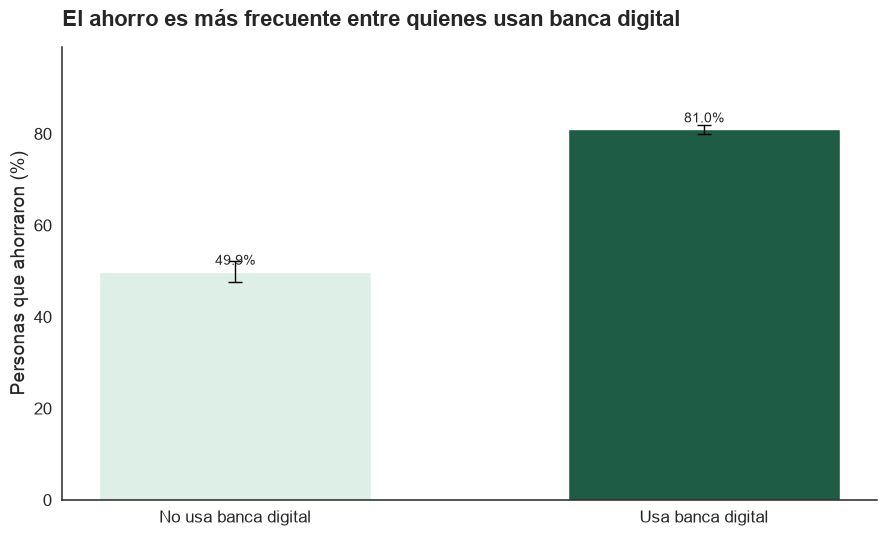


**Interpretación.** El porcentaje de personas que ahorraron pasa de 49.9% en «No usa banca digital» a 81.0% en «Usa banca digital». La diferencia descriptiva es de 31.1 puntos porcentuales.

**Conclusión.** El uso de banca digital identifica dos perfiles con distinta propensión observada al ahorro.

**Implicaciones.** Los canales digitales pueden funcionar como punto de contacto para facilitar hábitos de ahorro, aunque la relación también puede reflejar edad, ingresos, educación o mayor vinculación financiera.

**Recomendaciones.** Ofrecer reglas de ahorro automático, objetivos sencillos y recordatorios dentro de la banca digital; mantener alternativas asistidas para quienes no utilizan estos canales.


**Cautela metodológica.** La comparación es asociativa y no demuestra que utilizar banca digital cause una mayor capacidad de ahorro.

,grupo,n,porcentaje,ci_low,ci_high
0,No usa banca digital,1934,49.9,47.7,52.1
1,Usa banca digital,5814,81.0,80.0,82.0


In [22]:
# INS-02 — Ahorro y uso de banca digital

tmp = pd.DataFrame({
    "Ahorra": _binaria(df_analitico["ahorra_12m"]),
    "Banca digital": _binaria(df_analitico["usa_banca_digital"]),
}).dropna()

grupo = tmp["Banca digital"].map({0.0: "No usa banca digital", 1.0: "Usa banca digital"})
tabla_h01_digital = resumen_proporcion(tmp, grupo, tmp["Ahorra"])
orden = ["No usa banca digital", "Usa banca digital"]
tabla_h01_digital["grupo"] = pd.Categorical(tabla_h01_digital["grupo"], orden, ordered=True)
tabla_h01_digital = tabla_h01_digital.sort_values("grupo")

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(tabla_h01_digital))
y = tabla_h01_digital["porcentaje"].to_numpy()
err_low = y - tabla_h01_digital["ci_low"].to_numpy()
err_high = tabla_h01_digital["ci_high"].to_numpy() - y

ax.bar(x, y, color=[COLOR_NEUTRO, COLOR_PRINCIPAL], width=0.58)
ax.errorbar(x, y, yerr=[err_low, err_high], fmt="none", capsize=5, color="black", linewidth=1)
ax.set_xticks(x, tabla_h01_digital["grupo"])
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("El ahorro es más frecuente entre quienes usan banca digital", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h01_digital, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El porcentaje de personas que ahorraron pasa de {menor['porcentaje']:.1f}% "
            f"en «{menor['grupo']}» a {mayor['porcentaje']:.1f}% en «{mayor['grupo']}». "
            f"La diferencia descriptiva es de {dif:.1f} puntos porcentuales."
        ),
        conclusion=(
            "El uso de banca digital identifica dos perfiles con distinta propensión observada al ahorro."
        ),
        implicaciones=(
            "Los canales digitales pueden funcionar como punto de contacto para facilitar hábitos de ahorro, "
            "aunque la relación también puede reflejar edad, ingresos, educación o mayor vinculación financiera."
        ),
        recomendaciones=(
            "Ofrecer reglas de ahorro automático, objetivos sencillos y recordatorios dentro de la banca digital; "
            "mantener alternativas asistidas para quienes no utilizan estos canales."
        ),
        cautela=(
            "La comparación es asociativa y no demuestra que utilizar banca digital cause una mayor capacidad de ahorro."
        ),
    )

display(tabla_h01_digital[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))


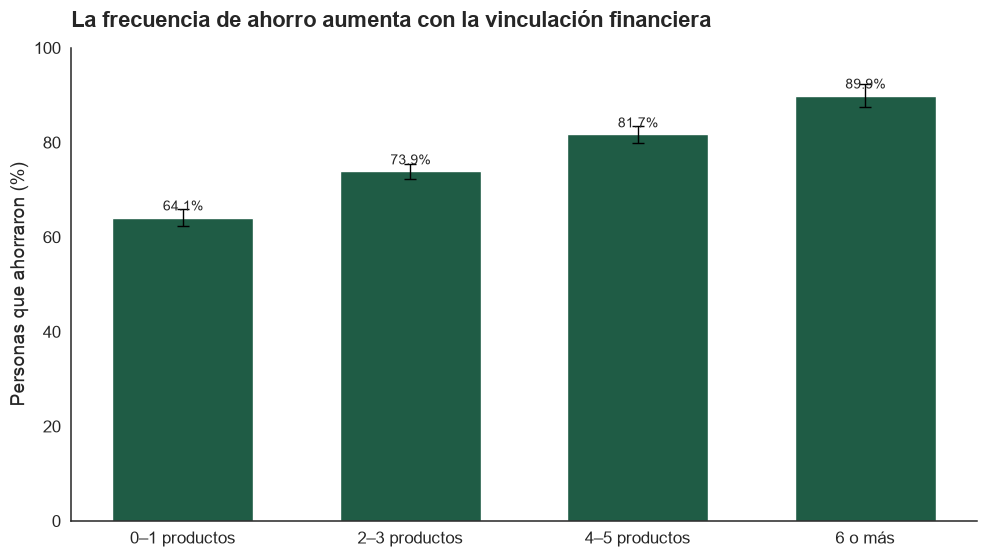


**Interpretación.** El grupo con menor porcentaje de ahorro es «0–1 productos» (64.1%), mientras que «6 o más» alcanza 89.9%. La distancia entre ambos grupos es de 25.8 puntos porcentuales.

**Conclusión.** Una relación financiera más diversificada se asocia con una mayor probabilidad observada de haber ahorrado.

**Implicaciones.** El número de productos puede reflejar mayor estabilidad económica, experiencia financiera o profundidad de la relación con las entidades.

**Recomendaciones.** No utilizar el gráfico como argumento de venta cruzada indiscriminada. Priorizar productos sencillos de ahorro cuando respondan a una necesidad real y acompañarlos de información clara.


**Cautela metodológica.** El número de productos puede ser consecuencia, y no causa, de una mayor capacidad económica y de ahorro.

,grupo,n,porcentaje,ci_low,ci_high
0,0–1 productos,2824,64.1,62.4,65.9
1,2–3 productos,2690,73.9,72.2,75.5
2,4–5 productos,1638,81.7,79.8,83.6
3,6 o más,603,89.9,87.5,92.3


In [23]:
# INS-04 — Ahorro según número de productos financieros

productos = _num(df_analitico["n_productos_financieros"])
tramos_productos = pd.cut(
    productos,
    bins=[-0.1, 1, 3, 5, np.inf],
    labels=["0–1 productos", "2–3 productos", "4–5 productos", "6 o más"],
    ordered=True,
)

tabla_h01_productos = resumen_proporcion(
    df_analitico,
    tramos_productos,
    df_analitico["ahorra_12m"],
)
orden = ["0–1 productos", "2–3 productos", "4–5 productos", "6 o más"]
tabla_h01_productos["grupo"] = pd.Categorical(tabla_h01_productos["grupo"], orden, ordered=True)
tabla_h01_productos = tabla_h01_productos.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_h01_productos))
y = tabla_h01_productos["porcentaje"].to_numpy()
err_low = y - tabla_h01_productos["ci_low"].to_numpy()
err_high = tabla_h01_productos["ci_high"].to_numpy() - y

ax.bar(x, y, color=COLOR_PRINCIPAL, width=0.62)
ax.errorbar(x, y, yerr=[err_low, err_high], fmt="none", capsize=4, color="black", linewidth=1)
ax.set_xticks(x, tabla_h01_productos["grupo"])
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("La frecuencia de ahorro aumenta con la vinculación financiera", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h01_productos, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El grupo con menor porcentaje de ahorro es «{menor['grupo']}» ({menor['porcentaje']:.1f}%), "
            f"mientras que «{mayor['grupo']}» alcanza {mayor['porcentaje']:.1f}%. "
            f"La distancia entre ambos grupos es de {dif:.1f} puntos porcentuales."
        ),
        conclusion=(
            "Una relación financiera más diversificada se asocia con una mayor probabilidad observada de haber ahorrado."
        ),
        implicaciones=(
            "El número de productos puede reflejar mayor estabilidad económica, experiencia financiera o profundidad "
            "de la relación con las entidades."
        ),
        recomendaciones=(
            "No utilizar el gráfico como argumento de venta cruzada indiscriminada. Priorizar productos sencillos de ahorro "
            "cuando respondan a una necesidad real y acompañarlos de información clara."
        ),
        cautela=(
            "El número de productos puede ser consecuencia, y no causa, de una mayor capacidad económica y de ahorro."
        ),
    )

display(tabla_h01_productos[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))


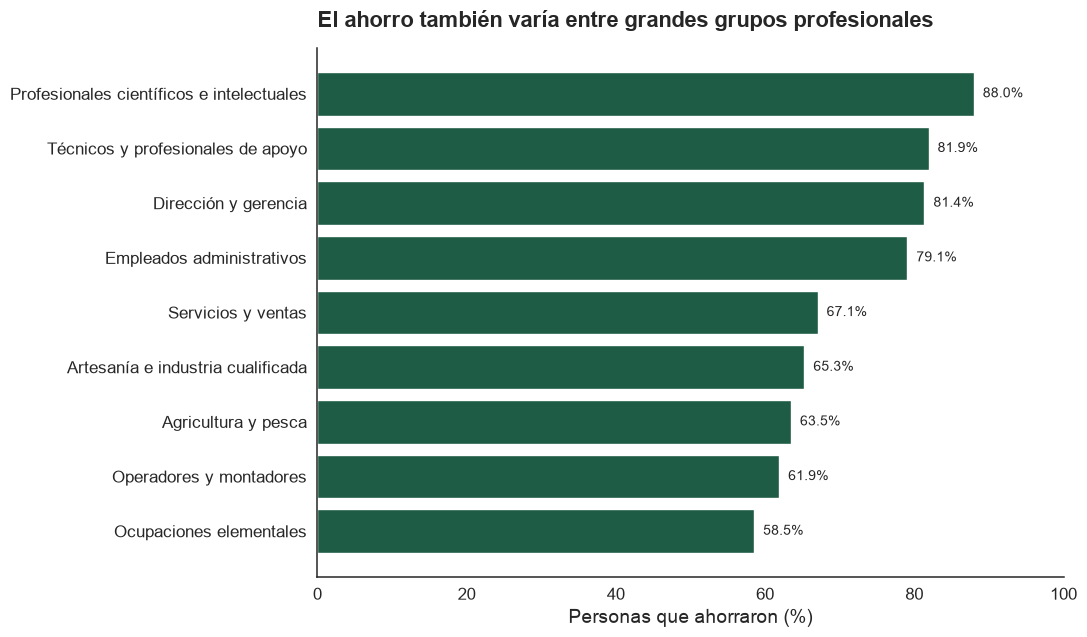


**Interpretación.** Entre los grupos con al menos 80 observaciones, «Profesionales científicos e intelectuales» presenta el porcentaje más alto de ahorro (88.0%) y «Ocupaciones elementales» el más bajo (58.5%). La diferencia descriptiva es de 29.4 puntos.

**Conclusión.** La ocupación ayuda a identificar desigualdades en la capacidad observada de ahorro.

**Implicaciones.** Las diferencias pueden estar captando estabilidad laboral, nivel de ingresos, edad o educación, por lo que no deben interpretarse como un efecto propio de la profesión.

**Recomendaciones.** Diseñar soluciones flexibles de microahorro y liquidez para perfiles con ingresos más variables; validar antes las diferencias mediante segmentación por edad e ingresos.


**Cautela metodológica.** La agrupación profesional simplifica los códigos CNO-11 y oculta heterogeneidad interna. Se excluyen grupos con menos de 80 casos para evitar comparaciones inestables.

,grupo,n,porcentaje,ci_low,ci_high
4,Ocupaciones elementales,849,58.5,55.2,61.9
6,Operadores y montadores,559,61.9,57.9,65.9
0,Agricultura y pesca,178,63.5,56.4,70.6
1,Artesanía e industria cualificada,812,65.3,62.0,68.5
8,Servicios y ventas,1560,67.1,64.7,69.4
3,Empleados administrativos,631,79.1,75.9,82.3
2,Dirección y gerencia,483,81.4,77.9,84.8
9,Técnicos y profesionales de apoyo,841,81.9,79.3,84.5
7,Profesionales científicos e intelectuales,1398,88.0,86.3,89.7


In [24]:
# INS-03 — Ahorro por grandes grupos profesionales

# CNO-11: agrupación por el primer dígito del código de ocupación.
mapa_cno = {
    0: "Ocupaciones militares",
    1: "Dirección y gerencia",
    2: "Profesionales científicos e intelectuales",
    3: "Técnicos y profesionales de apoyo",
    4: "Empleados administrativos",
    5: "Servicios y ventas",
    6: "Agricultura y pesca",
    7: "Artesanía e industria cualificada",
    8: "Operadores y montadores",
    9: "Ocupaciones elementales",
}

cno = _num(df_raw_codigos["a1800"])
primer_digito = np.floor(cno / 10)
grupo_profesion = primer_digito.map(mapa_cno)

tabla_h01_profesion = resumen_proporcion(
    df_analitico,
    grupo_profesion,
    df_analitico["ahorra_12m"],
)
# Evitar conclusiones sobre grupos con muy poca muestra.
tabla_h01_profesion = tabla_h01_profesion.query("n >= 80").sort_values("porcentaje")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(tabla_h01_profesion["grupo"], tabla_h01_profesion["porcentaje"], color=COLOR_PRINCIPAL)
ax.set_xlim(0, min(100, tabla_h01_profesion["porcentaje"].max() + 18))
ax.set_title("El ahorro también varía entre grandes grupos profesionales", loc="left", pad=15, weight="bold")
estilo_ejes(ax, xlabel="Personas que ahorraron (%)")
etiquetas_barras(ax, horizontal=True)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h01_profesion, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"Entre los grupos con al menos 80 observaciones, «{mayor['grupo']}» presenta el porcentaje "
            f"más alto de ahorro ({mayor['porcentaje']:.1f}%) y «{menor['grupo']}» el más bajo "
            f"({menor['porcentaje']:.1f}%). La diferencia descriptiva es de {dif:.1f} puntos."
        ),
        conclusion=(
            "La ocupación ayuda a identificar desigualdades en la capacidad observada de ahorro."
        ),
        implicaciones=(
            "Las diferencias pueden estar captando estabilidad laboral, nivel de ingresos, edad o educación, "
            "por lo que no deben interpretarse como un efecto propio de la profesión."
        ),
        recomendaciones=(
            "Diseñar soluciones flexibles de microahorro y liquidez para perfiles con ingresos más variables; "
            "validar antes las diferencias mediante segmentación por edad e ingresos."
        ),
        cautela=(
            "La agrupación profesional simplifica los códigos CNO-11 y oculta heterogeneidad interna. "
            "Se excluyen grupos con menos de 80 casos para evitar comparaciones inestables."
        ),
    )

display(tabla_h01_profesion[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))


## H03 — ¿Qué factores se relacionan con el uso de banca digital?

Insights incluidos:

- **INS-14:** número de productos financieros;
- **INS-15:** año de compra de la vivienda principal.


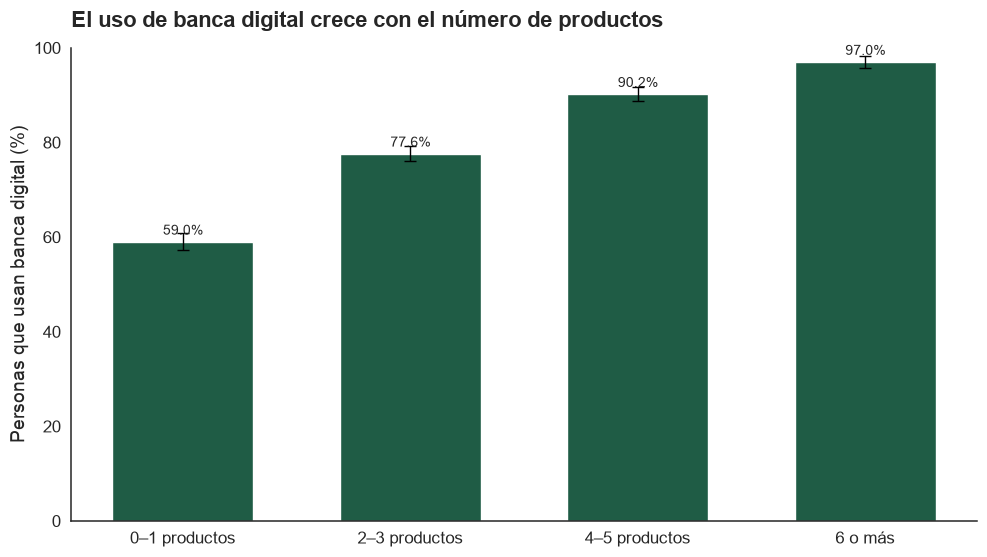


**Interpretación.** El uso de banca digital oscila entre 59.0% en «0–1 productos» y 97.0% en «6 o más», con una diferencia de 38.0 puntos.

**Conclusión.** La digitalización es más frecuente entre quienes mantienen una relación financiera más amplia.

**Implicaciones.** Los clientes con pocos productos pueden concentrar una mayor necesidad de acompañamiento digital o una menor intensidad de relación con el sistema financiero.

**Recomendaciones.** Simplificar el onboarding, ofrecer demostraciones guiadas y mantener canales híbridos para clientes con baja vinculación; evitar convertir la digitalización en una barrera de acceso.


**Cautela metodológica.** La dirección de la relación no está identificada: utilizar banca digital puede facilitar la contratación, pero una mayor vinculación también puede incentivar el uso digital.

,grupo,n,porcentaje,ci_low,ci_high
0,0–1 productos,2827,59.0,57.2,60.8
1,2–3 productos,2690,77.6,76.0,79.2
2,4–5 productos,1637,90.2,88.8,91.7
3,6 o más,603,97.0,95.7,98.4


In [25]:
# INS-14 — Uso de banca digital según número de productos financieros

tabla_h03_productos = resumen_proporcion(
    df_analitico,
    tramos_productos,
    df_analitico["usa_banca_digital"],
)
tabla_h03_productos["grupo"] = pd.Categorical(tabla_h03_productos["grupo"], orden, ordered=True)
tabla_h03_productos = tabla_h03_productos.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_h03_productos))
y = tabla_h03_productos["porcentaje"].to_numpy()
err_low = y - tabla_h03_productos["ci_low"].to_numpy()
err_high = tabla_h03_productos["ci_high"].to_numpy() - y

ax.bar(x, y, color=COLOR_PRINCIPAL, width=0.62)
ax.errorbar(x, y, yerr=[err_low, err_high], fmt="none", capsize=4, color="black", linewidth=1)
ax.set_xticks(x, tabla_h03_productos["grupo"])
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("El uso de banca digital crece con el número de productos", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que usan banca digital (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h03_productos, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El uso de banca digital oscila entre {menor['porcentaje']:.1f}% en «{menor['grupo']}» "
            f"y {mayor['porcentaje']:.1f}% en «{mayor['grupo']}», con una diferencia de {dif:.1f} puntos."
        ),
        conclusion=(
            "La digitalización es más frecuente entre quienes mantienen una relación financiera más amplia."
        ),
        implicaciones=(
            "Los clientes con pocos productos pueden concentrar una mayor necesidad de acompañamiento digital "
            "o una menor intensidad de relación con el sistema financiero."
        ),
        recomendaciones=(
            "Simplificar el onboarding, ofrecer demostraciones guiadas y mantener canales híbridos para clientes "
            "con baja vinculación; evitar convertir la digitalización en una barrera de acceso."
        ),
        cautela=(
            "La dirección de la relación no está identificada: utilizar banca digital puede facilitar la contratación, "
            "pero una mayor vinculación también puede incentivar el uso digital."
        ),
    )

display(tabla_h03_productos[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))


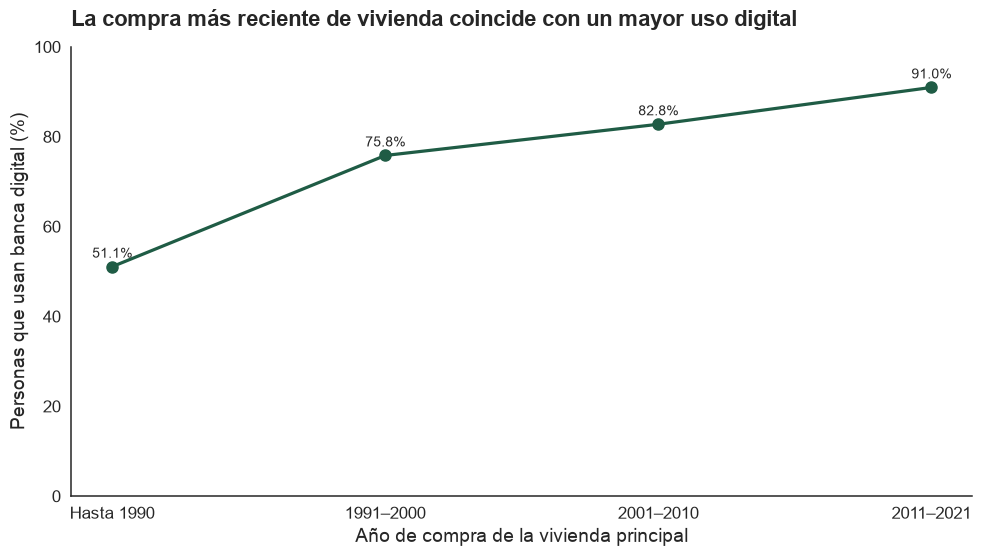


**Interpretación.** Entre propietarios con año válido, el uso digital alcanza su máximo en «2011–2021» (91.0%) y su mínimo en «Hasta 1990» (51.1%).

**Conclusión.** El año de compra de la vivienda funciona como marcador de perfiles generacionales y de relación reciente con servicios financieros, no como una causa directa de digitalización.

**Implicaciones.** Los propietarios de viviendas adquiridas hace más tiempo pueden concentrar mayores necesidades de apoyo en la transición a canales digitales.

**Recomendaciones.** Usar este hallazgo únicamente para orientar acompañamiento y comunicación; combinarlo con edad y competencias digitales antes de diseñar acciones.


**Cautela metodológica.** La pregunta solo aplica a propietarios y está fuertemente confundida por edad. No representa a toda la población.

,grupo,n,porcentaje,ci_low,ci_high
3,Hasta 1990,1026,51.1,48.0,54.1
0,1991–2000,1311,75.8,73.5,78.1
1,2001–2010,1520,82.8,80.9,84.7
2,2011–2021,1129,91.0,89.3,92.6


In [26]:
# INS-15 — Uso de banca digital según año de compra de la vivienda principal

anio_compra = _num(df_raw_codigos["i0800"])
anio_compra = anio_compra.where(anio_compra.between(1900, 2021))

tramos_compra = pd.cut(
    anio_compra,
    bins=[1899, 1990, 2000, 2010, 2021],
    labels=["Hasta 1990", "1991–2000", "2001–2010", "2011–2021"],
    ordered=True,
)

tabla_h03_vivienda = resumen_proporcion(
    df_analitico,
    tramos_compra,
    df_analitico["usa_banca_digital"],
)
orden_vivienda = ["Hasta 1990", "1991–2000", "2001–2010", "2011–2021"]
tabla_h03_vivienda["grupo"] = pd.Categorical(tabla_h03_vivienda["grupo"], orden_vivienda, ordered=True)
tabla_h03_vivienda = tabla_h03_vivienda.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
ax.plot(
    tabla_h03_vivienda["grupo"].astype(str),
    tabla_h03_vivienda["porcentaje"],
    marker="o",
    linewidth=2.3,
    markersize=8,
    color=COLOR_PRINCIPAL,
)
for _, r in tabla_h03_vivienda.iterrows():
    ax.text(str(r["grupo"]), r["porcentaje"] + 2, f"{r['porcentaje']:.1f}%", ha="center", fontsize=10)
ax.set_ylim(0, min(100, tabla_h03_vivienda["porcentaje"].max() + 16))
ax.set_title("La compra más reciente de vivienda coincide con un mayor uso digital", loc="left", pad=15, weight="bold")
estilo_ejes(ax, xlabel="Año de compra de la vivienda principal", ylabel="Personas que usan banca digital (%)")
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h03_vivienda, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"Entre propietarios con año válido, el uso digital alcanza su máximo en «{mayor['grupo']}» "
            f"({mayor['porcentaje']:.1f}%) y su mínimo en «{menor['grupo']}» ({menor['porcentaje']:.1f}%)."
        ),
        conclusion=(
            "El año de compra de la vivienda funciona como marcador de perfiles generacionales y de relación reciente "
            "con servicios financieros, no como una causa directa de digitalización."
        ),
        implicaciones=(
            "Los propietarios de viviendas adquiridas hace más tiempo pueden concentrar mayores necesidades de apoyo "
            "en la transición a canales digitales."
        ),
        recomendaciones=(
            "Usar este hallazgo únicamente para orientar acompañamiento y comunicación; combinarlo con edad y competencias "
            "digitales antes de diseñar acciones."
        ),
        cautela=(
            "La pregunta solo aplica a propietarios y está fuertemente confundida por edad. No representa a toda la población."
        ),
    )

display(tabla_h03_vivienda[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))


## H04 — ¿Qué factores se asocian con una mayor diversificación de productos financieros?

Insight incluido:

- **INS-17:** haber oído hablar de las hipotecas.


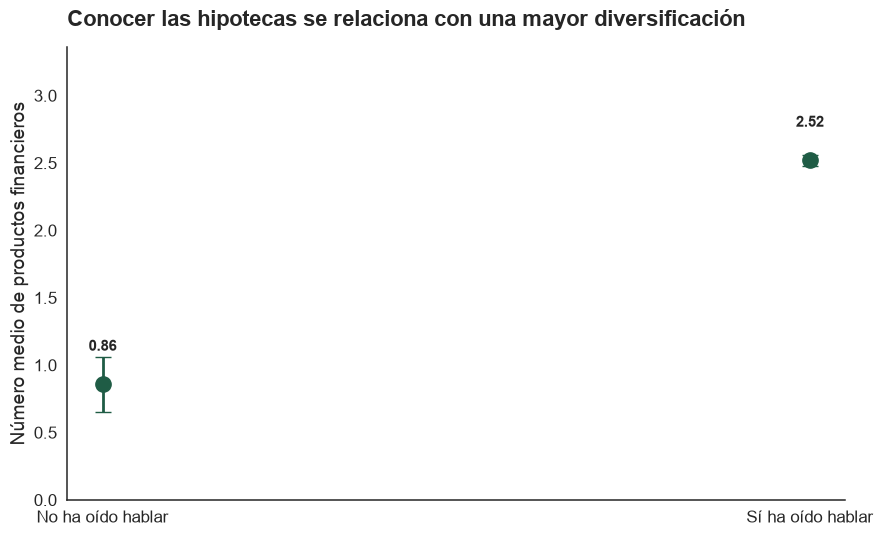


**Interpretación.** Quienes «sí ha oído hablar» presentan una media de 2.52 productos, frente a 0.86 en el otro grupo; la diferencia es de 1.66 productos.

**Conclusión.** El conocimiento declarado de un producto financiero se asocia con una relación más diversificada, pero el hallazgo tiene una capacidad discriminante limitada.

**Implicaciones.** La familiaridad con productos puede acompañar una mayor experiencia financiera, aunque no implica necesariamente comprensión profunda ni decisiones adecuadas.

**Recomendaciones.** Mantener este insight como apoyo secundario, no como mensaje central. Priorizar información clara sobre utilidad, costes y riesgos antes que la simple notoriedad del producto.


**Cautela metodológica.** La gran mayoría de la muestra ha oído hablar de las hipotecas, por lo que el grupo «No» es pequeño y la comparación puede ser inestable. Además, este insight roza el ámbito de conocimiento financiero.

,grupo,n,media,ci_low,ci_high
0,No ha oído hablar,119,0.86,0.65,1.06
1,Sí ha oído hablar,7645,2.52,2.48,2.56


In [27]:
# INS-17 — Número medio de productos según conocimiento declarado de las hipotecas

conoce_hipoteca = _binaria(df_analitico["b0201"])
grupo_hipoteca = conoce_hipoteca.map({0.0: "No ha oído hablar", 1.0: "Sí ha oído hablar"})

tabla_h04_hipoteca = resumen_media(
    df_analitico,
    grupo_hipoteca,
    df_analitico["n_productos_financieros"],
)
orden_hipoteca = ["No ha oído hablar", "Sí ha oído hablar"]
tabla_h04_hipoteca["grupo"] = pd.Categorical(tabla_h04_hipoteca["grupo"], orden_hipoteca, ordered=True)
tabla_h04_hipoteca = tabla_h04_hipoteca.sort_values("grupo")

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(tabla_h04_hipoteca))
y = tabla_h04_hipoteca["media"].to_numpy()
err_low = y - tabla_h04_hipoteca["ci_low"].to_numpy()
err_high = tabla_h04_hipoteca["ci_high"].to_numpy() - y

ax.errorbar(
    x, y, yerr=[err_low, err_high],
    fmt="o", markersize=11, capsize=6, linewidth=2,
    color=COLOR_PRINCIPAL,
)
ax.set_xticks(x, tabla_h04_hipoteca["grupo"])
ax.set_ylim(0, max(tabla_h04_hipoteca["ci_high"]) + 0.8)
ax.set_title("Conocer las hipotecas se relaciona con una mayor diversificación", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Número medio de productos financieros")
for i, valor in enumerate(y):
    ax.text(i, valor + 0.25, f"{valor:.2f}", ha="center", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_h04_hipoteca, "media")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"Quienes «{mayor['grupo'].lower()}» presentan una media de {mayor['media']:.2f} productos, "
            f"frente a {menor['media']:.2f} en el otro grupo; la diferencia es de {dif:.2f} productos."
        ),
        conclusion=(
            "El conocimiento declarado de un producto financiero se asocia con una relación más diversificada, "
            "pero el hallazgo tiene una capacidad discriminante limitada."
        ),
        implicaciones=(
            "La familiaridad con productos puede acompañar una mayor experiencia financiera, aunque no implica necesariamente "
            "comprensión profunda ni decisiones adecuadas."
        ),
        recomendaciones=(
            "Mantener este insight como apoyo secundario, no como mensaje central. Priorizar información clara sobre utilidad, "
            "costes y riesgos antes que la simple notoriedad del producto."
        ),
        cautela=(
            "La gran mayoría de la muestra ha oído hablar de las hipotecas, por lo que el grupo «No» es pequeño y la comparación "
            "puede ser inestable. Además, este insight roza el ámbito de conocimiento financiero."
        ),
    )

display(tabla_h04_hipoteca[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))


## H02 — ¿Qué factores caracterizan una mayor fragilidad financiera?

Insights incluidos:

- **INS-07:** puntos del ingreso extraordinario destinados a pagar deudas;
- **INS-10:** respuesta original `d0610d`.

Ambos insights representan la misma variable conceptual. Se integran en un único gráfico para evitar duplicidad.


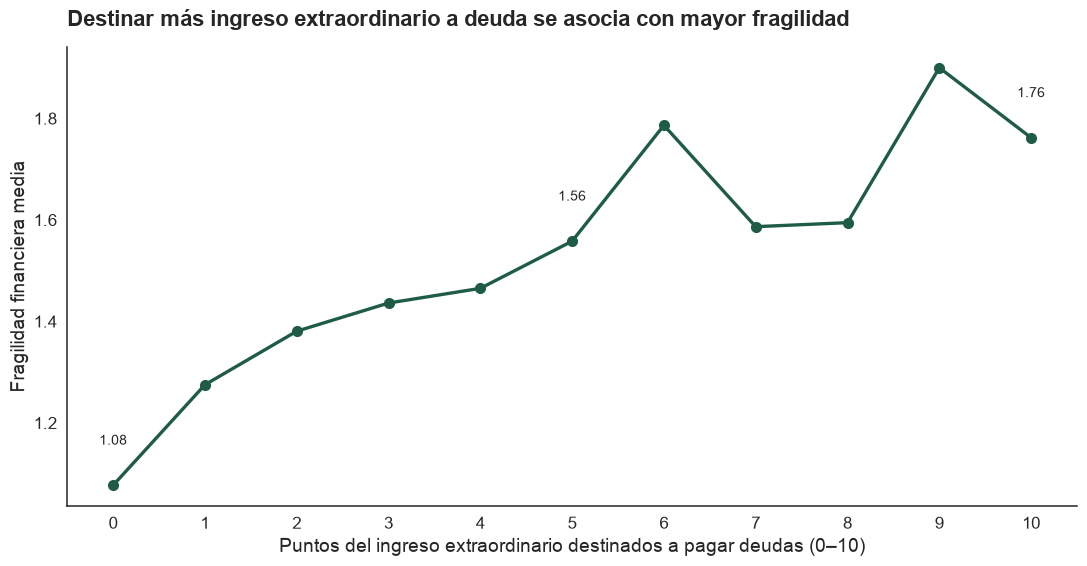


**Interpretación.** La fragilidad media pasa de 1.08 entre quienes asignan 0 puntos a pagar deudas a 1.76 entre quienes asignan los 10 puntos. La diferencia descriptiva es de 0.69 puntos de fragilidad.

**Conclusión.** La prioridad que una persona concede al pago de deudas ante un ingreso inesperado actúa como una señal conductual de presión financiera.

**Implicaciones.** Este comportamiento puede ayudar a detectar hogares con menor margen de liquidez y mayor exposición a tensiones financieras, incluso antes de observar un impago.

**Recomendaciones.** Ofrecer herramientas de reorganización de pagos, fondos de emergencia y acompañamiento presupuestario. Evitar utilizar esta señal de forma automática para excluir clientes o encarecer productos.


**Cautela metodológica.** La variable refleja una intención declarada ante una situación hipotética. Además, pagar deuda puede ser una decisión financieramente responsable y no siempre implica vulnerabilidad.

,puntos,n,media,ci_low,ci_high
0,0,4714,1.08,1.05,1.1
1,1,389,1.28,1.18,1.37
3,2,599,1.38,1.3,1.46
4,3,376,1.44,1.33,1.54
5,4,215,1.47,1.33,1.6
6,5,525,1.56,1.47,1.65
7,6,89,1.79,1.56,2.01
8,7,75,1.59,1.35,1.82
9,8,74,1.59,1.34,1.85
10,9,10,1.9,1.05,2.75


In [28]:
# INS-07 + INS-10 — Fragilidad financiera y destino de un ingreso extraordinario

puntos_deuda = _num(df_raw_codigos["d0610d"])
puntos_deuda = puntos_deuda.where(puntos_deuda.between(0, 10))

tabla_h02_deuda = resumen_media(
    df_analitico,
    puntos_deuda.astype("Int64").astype("string"),
    df_analitico["score_fragilidad_financiera"],
)
tabla_h02_deuda["puntos"] = pd.to_numeric(tabla_h02_deuda["grupo"], errors="coerce")
tabla_h02_deuda = tabla_h02_deuda.dropna(subset=["puntos"]).sort_values("puntos")

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(
    tabla_h02_deuda["puntos"],
    tabla_h02_deuda["media"],
    marker="o",
    linewidth=2.4,
    markersize=7,
    color=COLOR_PRINCIPAL,
)
ax.set_xticks(range(0, 11))
ax.set_title("Destinar más ingreso extraordinario a deuda se asocia con mayor fragilidad", loc="left", pad=15, weight="bold")
estilo_ejes(
    ax,
    xlabel="Puntos del ingreso extraordinario destinados a pagar deudas (0–10)",
    ylabel="Fragilidad financiera media",
)
for _, r in tabla_h02_deuda.iterrows():
    if int(r["puntos"]) in {0, 5, 10}:
        ax.text(r["puntos"], r["media"] + 0.08, f"{r['media']:.2f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# Comparación resumida de los extremos para facilitar la lectura ejecutiva.
extremos = tabla_h02_deuda[tabla_h02_deuda["puntos"].isin([0, 10])].copy()
if len(extremos) == 2:
    cero = extremos.loc[extremos["puntos"].eq(0)].iloc[0]
    diez = extremos.loc[extremos["puntos"].eq(10)].iloc[0]
    diferencia = diez["media"] - cero["media"]
    interpretacion = (
        f"La fragilidad media pasa de {cero['media']:.2f} entre quienes asignan 0 puntos a pagar deudas "
        f"a {diez['media']:.2f} entre quienes asignan los 10 puntos. "
        f"La diferencia descriptiva es de {diferencia:.2f} puntos de fragilidad."
    )
else:
    ext = diferencia_extremos(tabla_h02_deuda, "media")
    menor, mayor, diferencia = ext
    interpretacion = (
        f"La fragilidad media más baja es {menor['media']:.2f} con {int(menor['puntos'])} puntos destinados a deuda, "
        f"y la más alta es {mayor['media']:.2f} con {int(mayor['puntos'])} puntos."
    )

bloque_texto(
    interpretacion=interpretacion,
    conclusion=(
        "La prioridad que una persona concede al pago de deudas ante un ingreso inesperado actúa como una señal conductual "
        "de presión financiera."
    ),
    implicaciones=(
        "Este comportamiento puede ayudar a detectar hogares con menor margen de liquidez y mayor exposición a tensiones "
        "financieras, incluso antes de observar un impago."
    ),
    recomendaciones=(
        "Ofrecer herramientas de reorganización de pagos, fondos de emergencia y acompañamiento presupuestario. "
        "Evitar utilizar esta señal de forma automática para excluir clientes o encarecer productos."
    ),
    cautela=(
        "La variable refleja una intención declarada ante una situación hipotética. Además, pagar deuda puede ser una decisión "
        "financieramente responsable y no siempre implica vulnerabilidad."
    ),
)

display(tabla_h02_deuda[["puntos", "n", "media", "ci_low", "ci_high"]].round(2))


## Síntesis final de la Fase 4

Los gráficos anteriores responden a cuatro preguntas de comportamiento:

1. **Ahorro:** se relaciona con el uso de banca digital, una mayor vinculación financiera y diferencias profesionales.
2. **Digitalización:** es más frecuente entre personas con más productos y entre propietarios con compras de vivienda más recientes.
3. **Diversificación:** se asocia con la familiaridad declarada con productos, aunque este hallazgo debe mantenerse como secundario.
4. **Fragilidad:** la intención de destinar una mayor parte de un ingreso extraordinario al pago de deudas funciona como señal conductual de presión financiera.

### Criterio para la presentación final

No todos los gráficos tienen que llegar a las diapositivas. La selección ejecutiva debería priorizar:

- ahorro y banca digital;
- ahorro y número de productos;
- banca digital y número de productos;
- fragilidad y destino del ingreso extraordinario.

Los gráficos de profesión, año de compra de vivienda y conocimiento de hipotecas deben considerarse complementarios o de reserva debido a sus mayores riesgos de confusión, cobertura o interpretación.
